# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 18     |  |
| :-------------|:-------------|
| Tim Mekkelholt| 6224687 |
| Laura Otto | 6488463 |
| Justin Sloots | 6541313 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Tim', 'Laura','Justin']

## Opdracht 1: Planning.

| Planning Groep: 18     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie sensor gedaan | 11:30 |
| Eerste testmeting gedaan | 12:00 |
| Meetplan uitwerken | 12:00-12:30 |
| Optestellen/eerste meting| 13:45-14:45 |
| Iteraties uitvoeren | 15:00-16:30 |
| Algoritme presenteren | 16:30-17:00 |
| Afronden en opruimen | 17:00-17:30 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| 14:45-15:00 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit
# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep 18
<img src="Kalibratieopstelling.jpg" width="400">

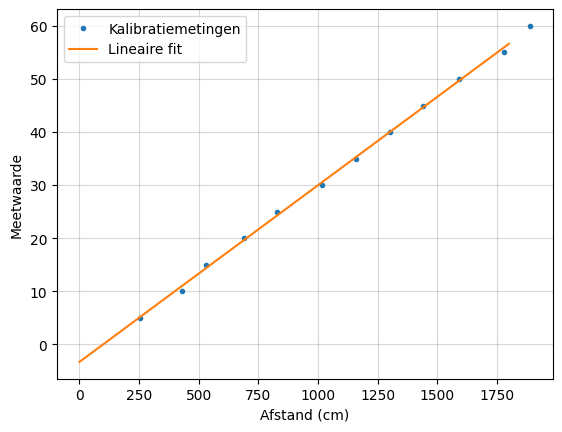

De parameters van de lineaire fit zijn: a = 0.0333, b = -3.33


In [3]:
# verwerk hier jullie kalibratiemetingen
afstanden = np.array([5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60])
meetwaarden = np.array([253, 430, 530, 690, 830, 1015, 1160, 1300, 1440, 1590, 1780, 1890])

def line (x, a, b):
    return a*x + b
x_fit = np.linspace(0, 1800, 1000)

popt, pcov = curve_fit(line, meetwaarden, afstanden)


plt.figure()
plt.plot( meetwaarden,afstanden, '.', label='Kalibratiemetingen')
plt.plot( x_fit, line(x_fit, popt[0], popt[1]), label='Lineaire fit')
plt.xlabel('Afstand (cm)')  
plt.ylabel('Meetwaarde')
plt.grid(alpha=0.5)
plt.legend()
plt.show()
print(f"De parameters van de lineaire fit zijn: a = {popt[0]:.4f}, b = {popt[1]:.2f}")



## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  45.0
1   0  30   0  20  43.5
2  40   0  30   0  48.5
3  30   0  20   0  46.2


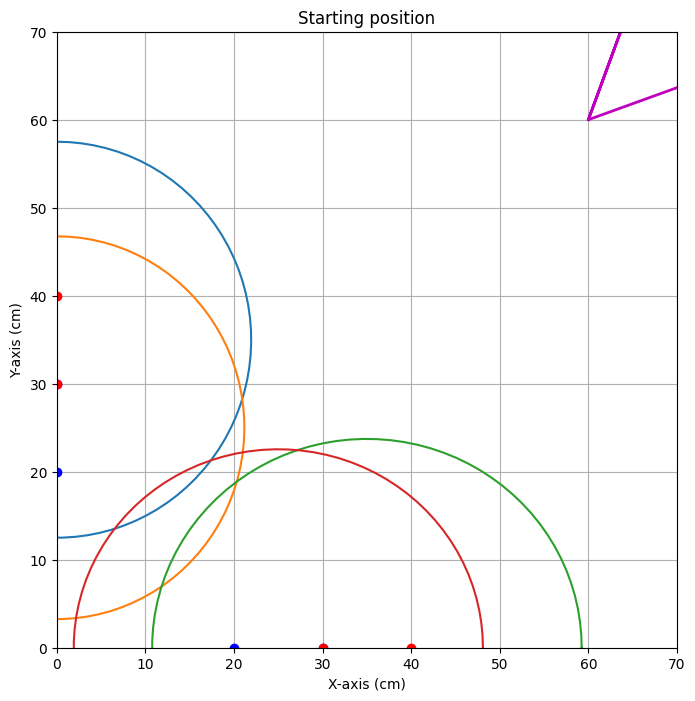


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=96.155
end iteration 2 with average mismatch=88.448


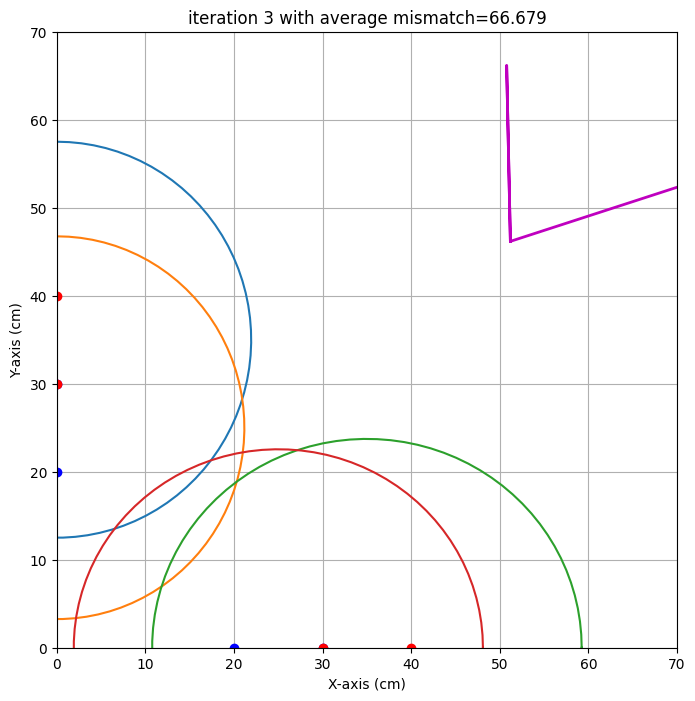

end iteration 3 with average mismatch=66.679


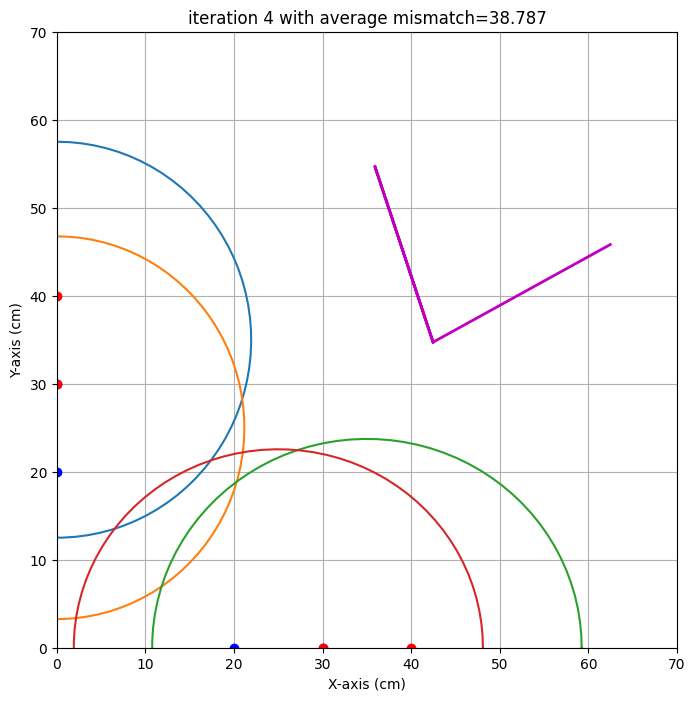

end iteration 4 with average mismatch=38.787


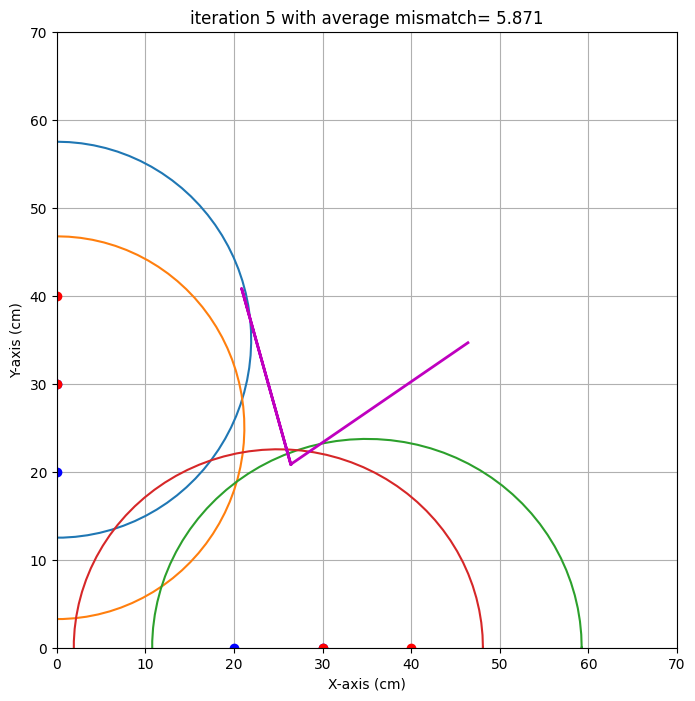

end iteration 5 with average mismatch= 5.871


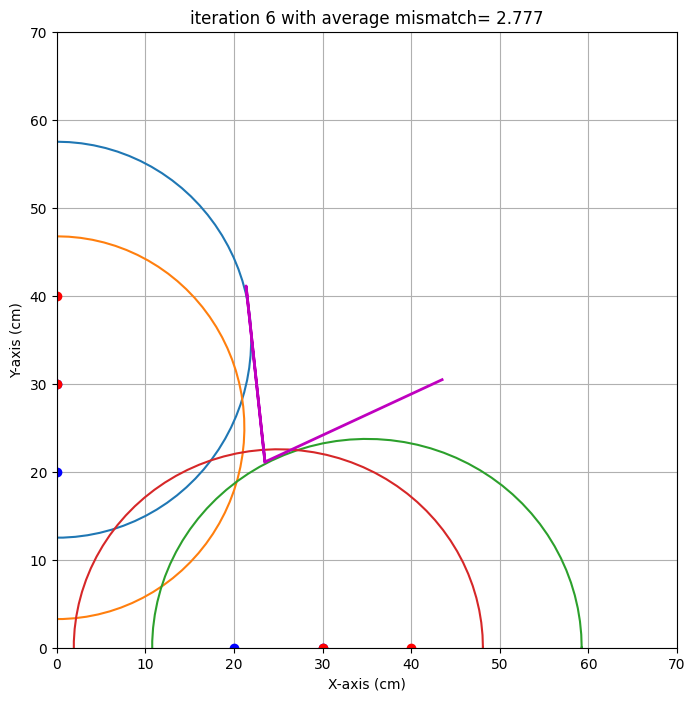

end iteration 6 with average mismatch= 2.777
end iteration 7 with average mismatch= 2.543


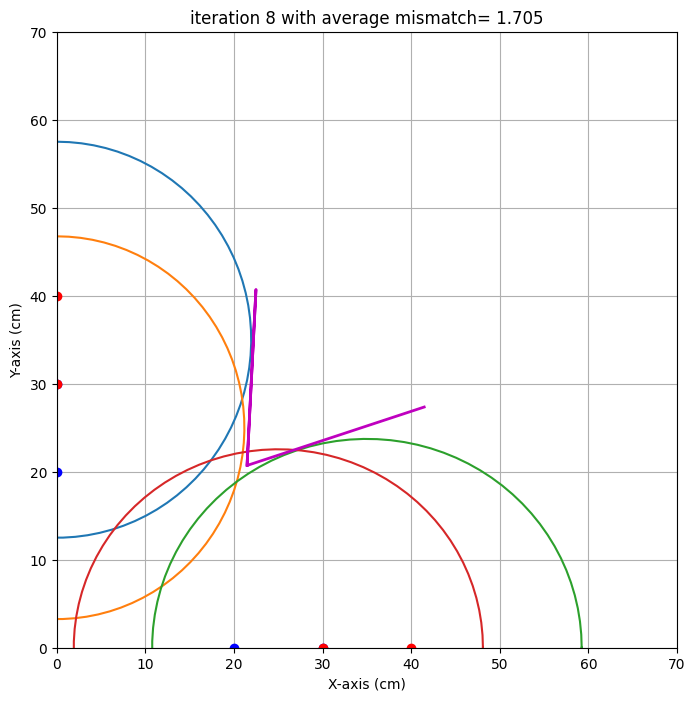

end iteration 8 with average mismatch= 1.705


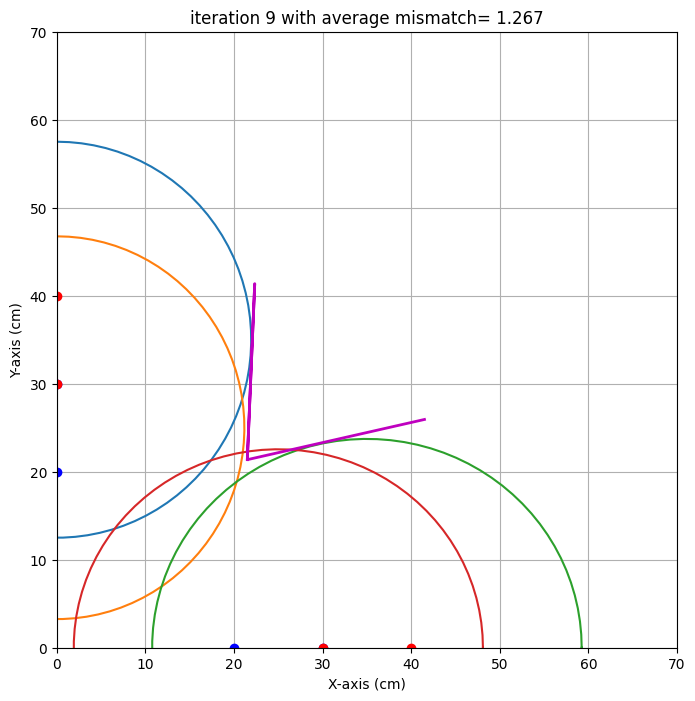

end iteration 9 with average mismatch= 1.267


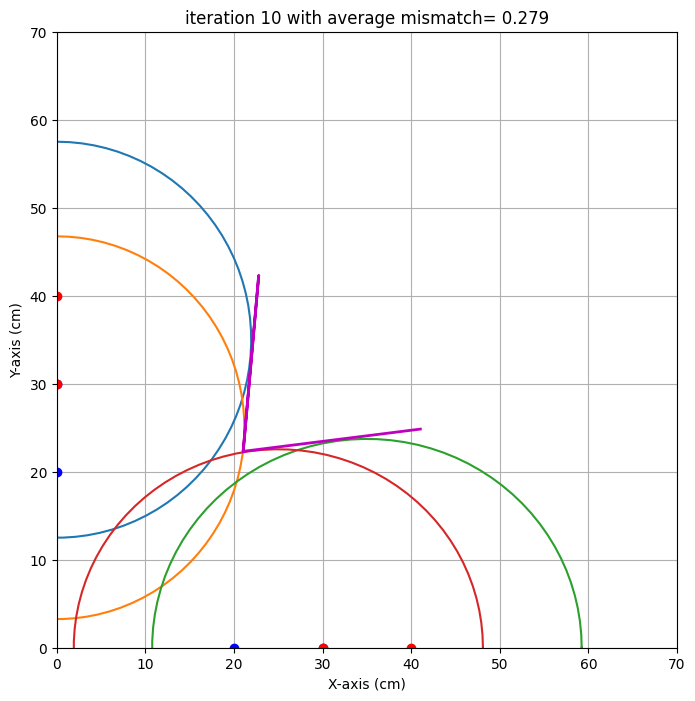

end iteration 10 with average mismatch= 0.279


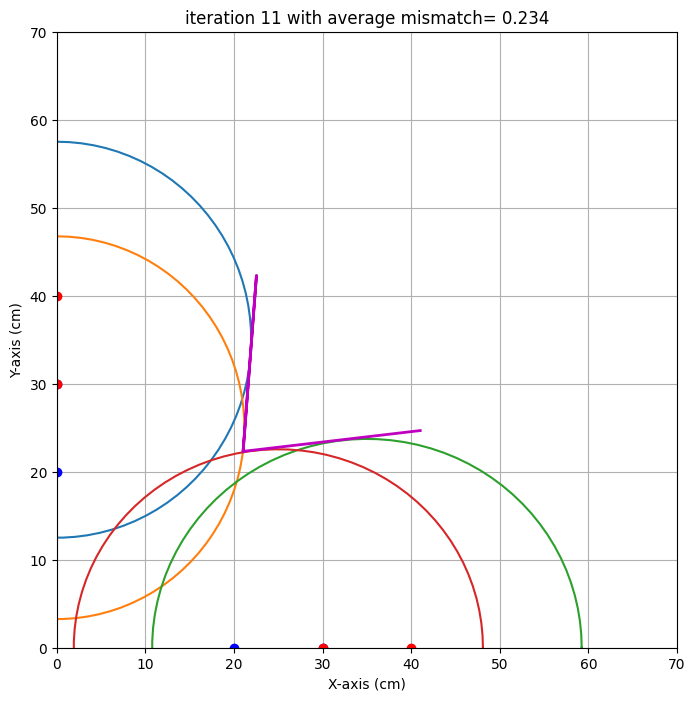

end iteration 11 with average mismatch= 0.234


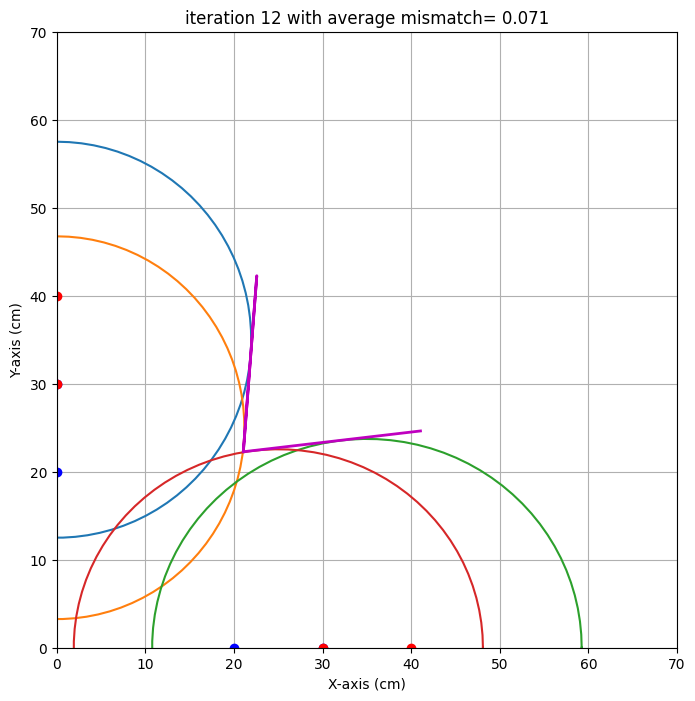

end iteration 12 with average mismatch= 0.071


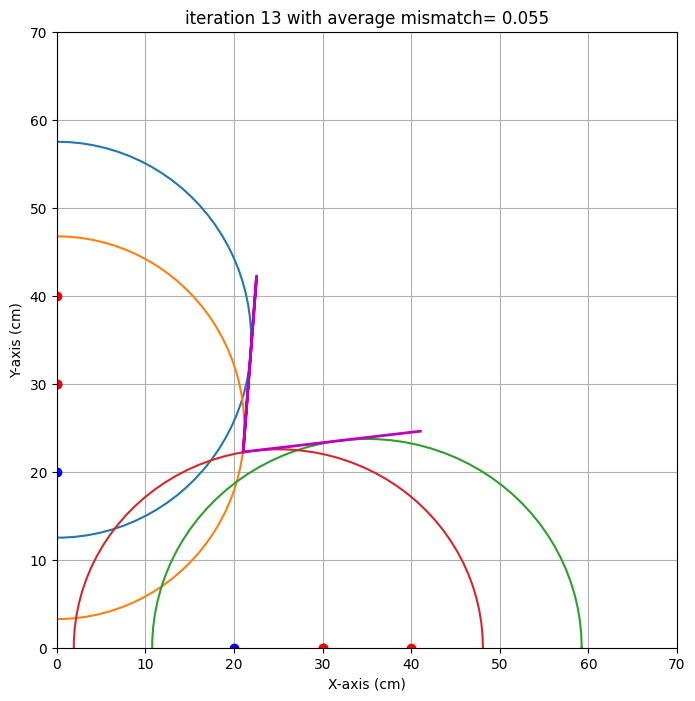

end iteration 13 with average mismatch= 0.055
end iteration 14 with average mismatch= 0.055
end iteration 15 with average mismatch= 0.055
end iteration 16 with average mismatch= 0.055
end iteration 17 with average mismatch= 0.055
end iteration 18 with average mismatch= 0.055
end iteration 19 with average mismatch= 0.055
end iteration 20 with average mismatch= 0.055
end iteration 21 with average mismatch= 0.055
end iteration 22 with average mismatch= 0.055
end iteration 23 with average mismatch= 0.055
end iteration 24 with average mismatch= 0.055
end iteration 25 with average mismatch= 0.055
end iteration 26 with average mismatch= 0.055
end iteration 27 with average mismatch= 0.055
end iteration 28 with average mismatch= 0.055
end iteration 29 with average mismatch= 0.055
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.055
###############################################################

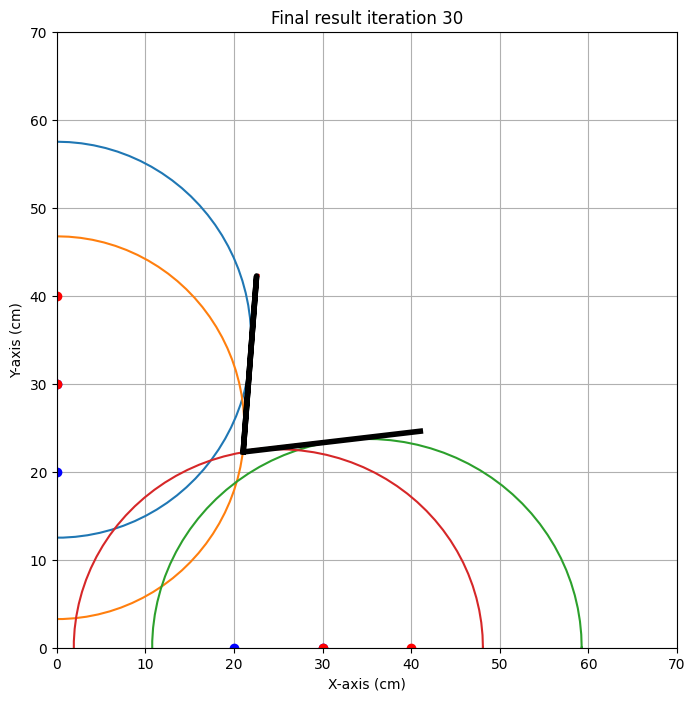

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,45.0],
    [0,30,0,20,43.5],
    #[0,10,0,20,135.0],
    [40,0,30,0,48.5],
    [30,0,20,0,46.2],
    #[10,0,20,0,190],
    #[10,0,0,10,150]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 21.0 cm met een standaardafwijking van 0.1 cm 
y0: 22.2 cm met een standaardafwijking van 0.2 cm 
alpha: 6.7 graden met een standaardafwijking van 0.1 graad 
beta: 4.3 graden met een standaardafwijking van 0.4 graad 



## Opdracht 5: Iteratie 0

#### algoritme Justin
<img src="algoritme3.jpg" width="400">

#### algoritme Laura
<img src="Algoritme2.jpg" width="400">

#### algoritme Tim
<img src="Algoritme1.jpg" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 29,
           'y0': 43,
           'alpha' : 0, 
           'beta' : 29, 
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Tim' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [40, 0, 30, 0, 87.0],
    [35, 0, 25, 0, 86.5],
    [0, 68, 0, 58, 67.0],
    [0, 66, 0, 56, 84.0],
    ]),
       'Laura' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [42, 0, 33, 0, 86.0],
    [47, 0, 38, 0, 84.2],
    [0, 51, 0, 68, 73],
    [0, 52, 0, 67, 71]
    ]),
       'Justin' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [20, 0, 30, 0, 86.7],
    [25, 0, 35, 0, 85.0],
    [0, 52, 0, 62, 66],
    [0, 57, 0, 67, 66],
    ])
      }

## Opdracht 7: Evaluatie.

Tim
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  30   0  87.0
1  35   0  25   0  86.5
2   0  68   0  58  67.0
3   0  66   0  56  84.0


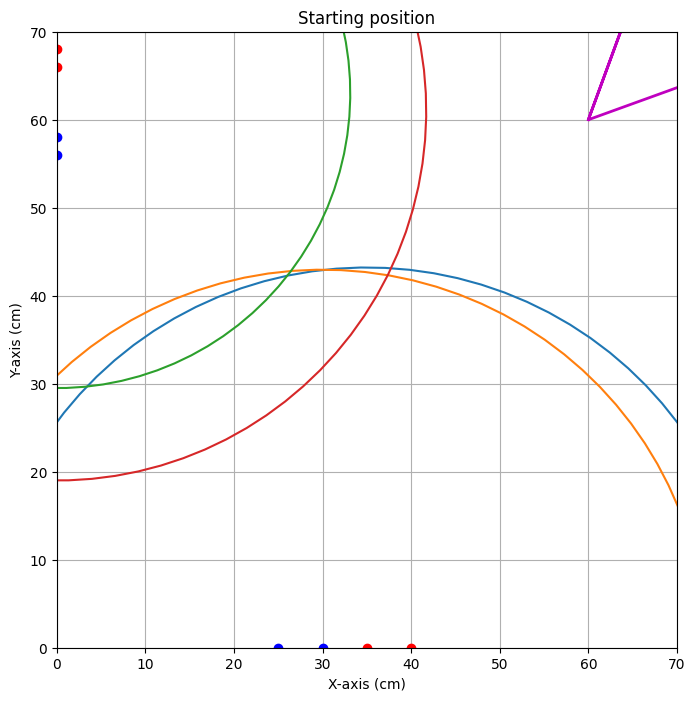


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=50.386


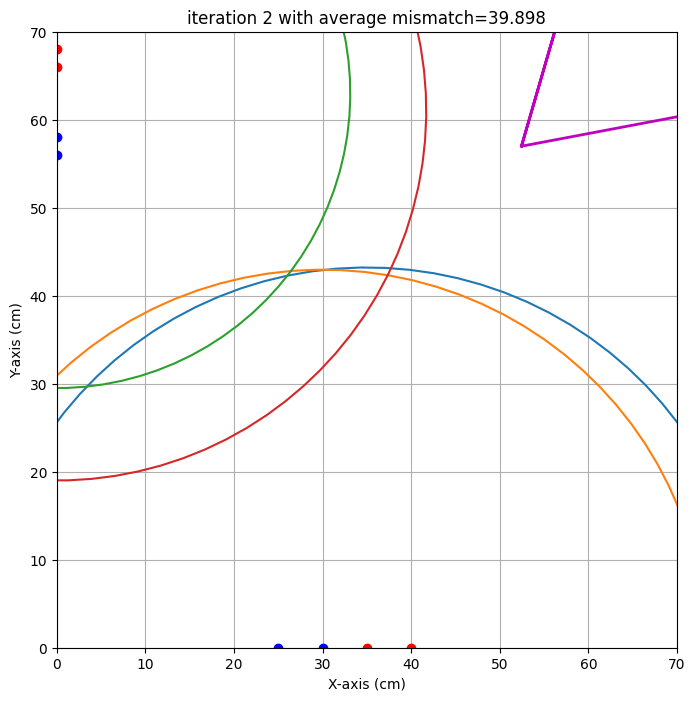

end iteration 2 with average mismatch=39.898


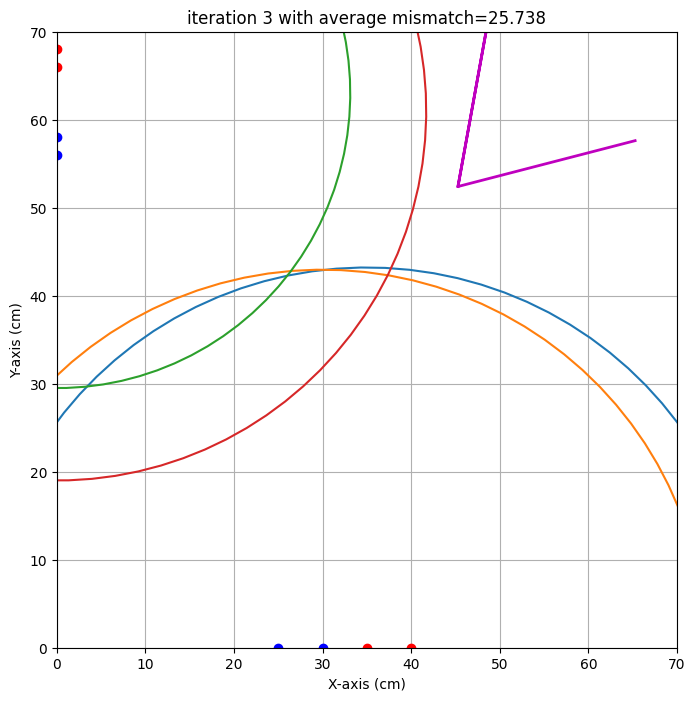

end iteration 3 with average mismatch=25.738


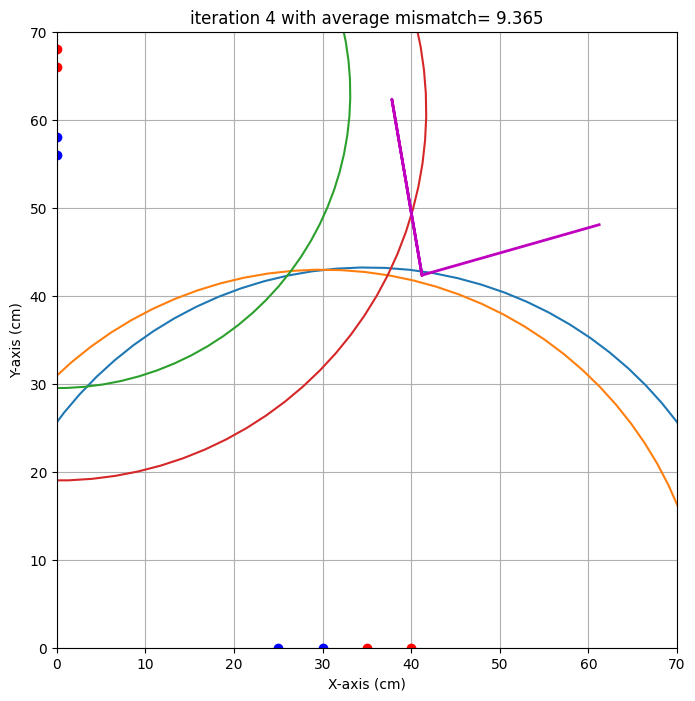

end iteration 4 with average mismatch= 9.365


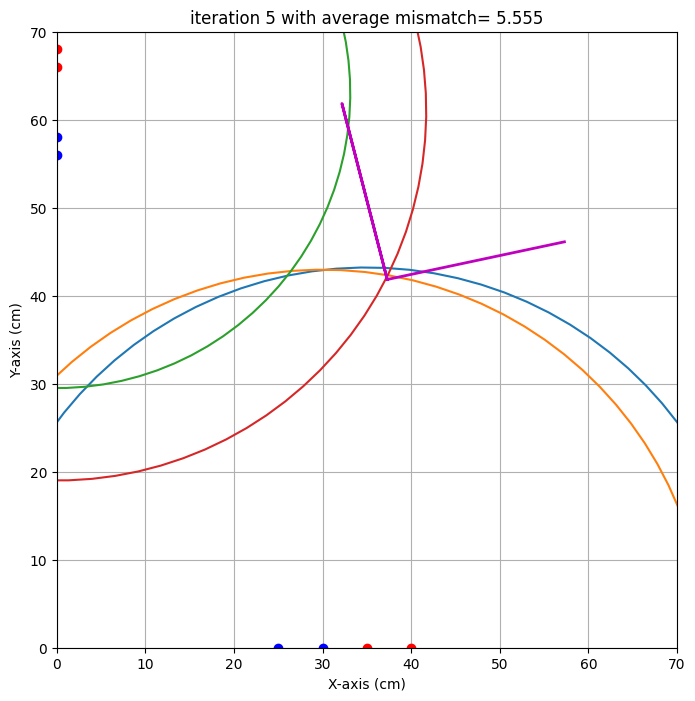

end iteration 5 with average mismatch= 5.555


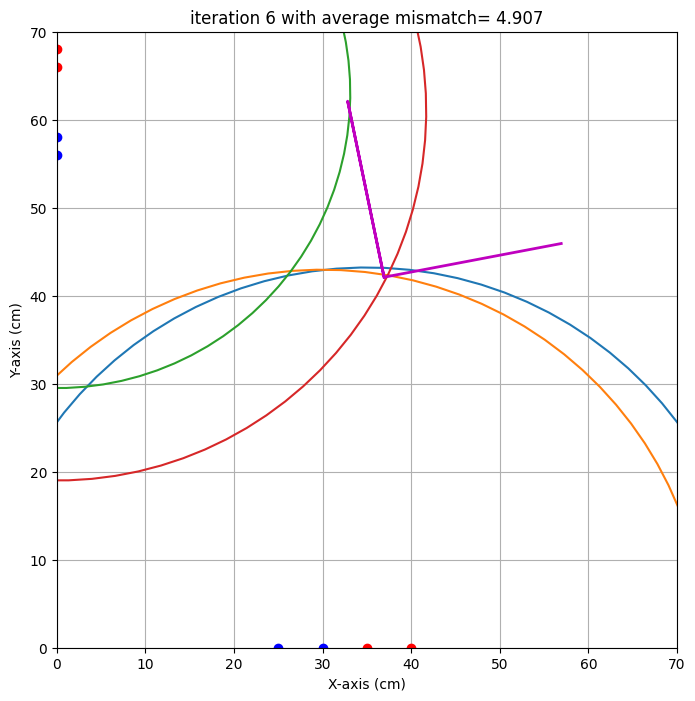

end iteration 6 with average mismatch= 4.907
end iteration 7 with average mismatch= 4.887
end iteration 8 with average mismatch= 4.686
end iteration 9 with average mismatch= 4.680
end iteration 10 with average mismatch= 4.677
end iteration 11 with average mismatch= 4.532
end iteration 12 with average mismatch= 4.529
end iteration 13 with average mismatch= 4.529
end iteration 14 with average mismatch= 4.412
end iteration 15 with average mismatch= 4.412
end iteration 16 with average mismatch= 4.196
end iteration 17 with average mismatch= 4.196
end iteration 18 with average mismatch= 4.025
end iteration 19 with average mismatch= 4.025
end iteration 20 with average mismatch= 4.025
end iteration 21 with average mismatch= 3.808
end iteration 22 with average mismatch= 3.808
end iteration 23 with average mismatch= 3.808
end iteration 24 with average mismatch= 3.808
end iteration 25 with average mismatch= 3.808
end iteration 26 with average mismatch= 3.808
end iteration 27 with average mismatch

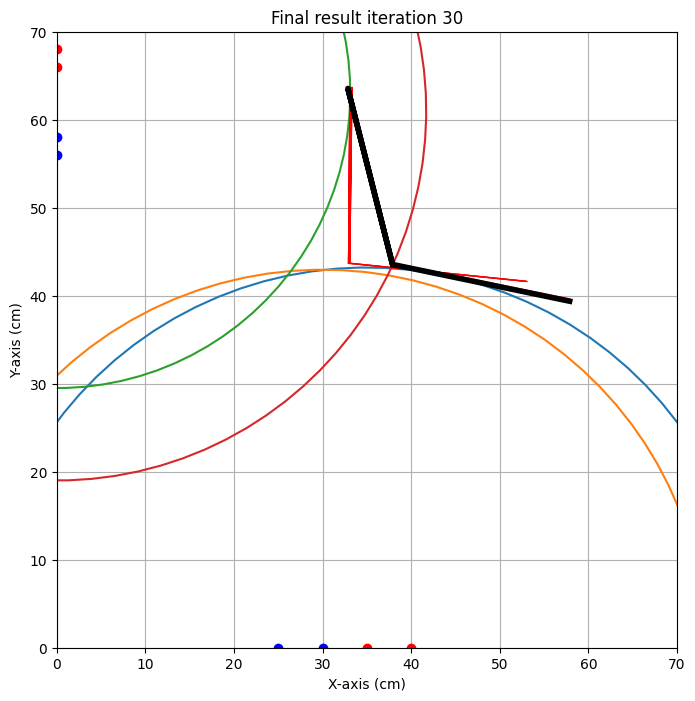

{'alpha': np.float64(-11.803467970262531), 'alpha_eps': np.float64(5.948776043065811), 'beta': np.float64(-14.149965124709967), 'beta_eps': np.float64(14.871286896824328), 'x0': np.float64(37.890648027308735), 'x0_eps': np.float64(4.960021357801395), 'y0': np.float64(43.55335534293356), 'y0_eps': np.float64(0.16287782775224002)}
Laura
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  42   0  33   0  86.0
1  47   0  38   0  84.2
2   0  51   0  68  73.0
3   0  52   0  67  71.0


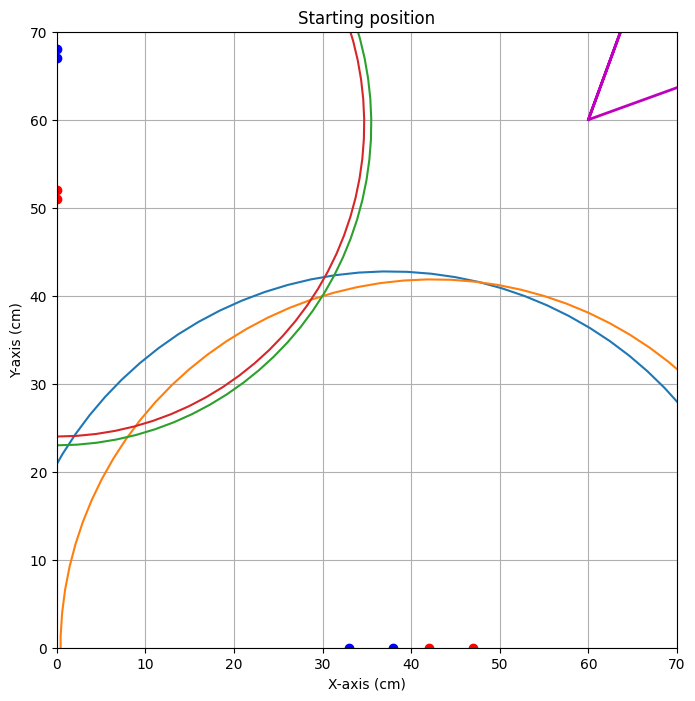


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=50.798


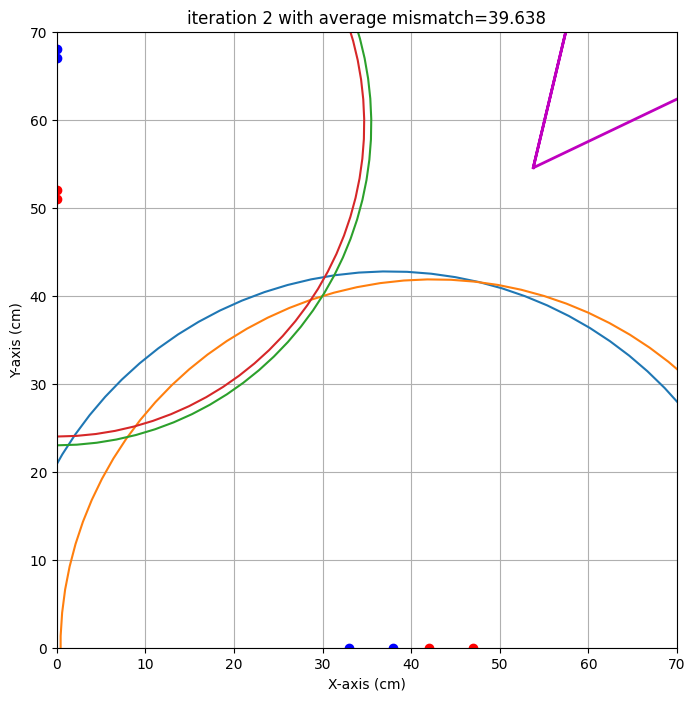

end iteration 2 with average mismatch=39.638


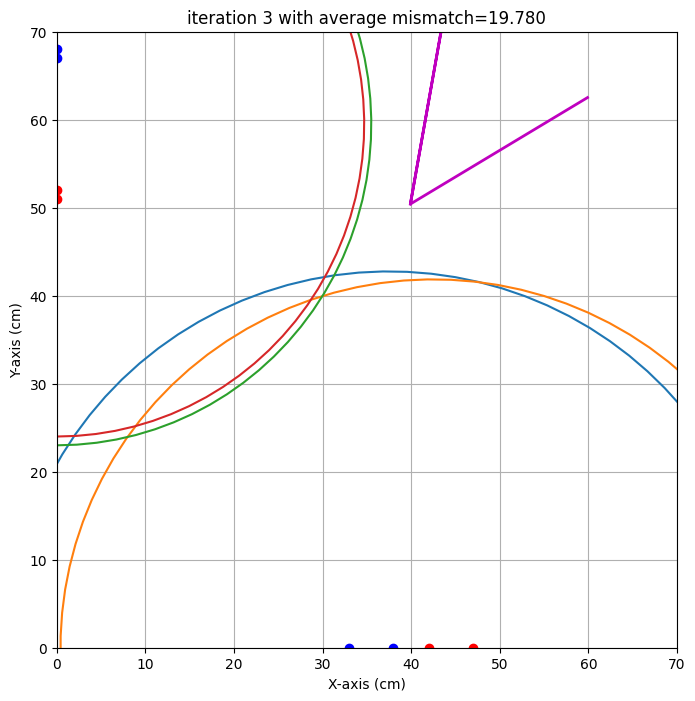

end iteration 3 with average mismatch=19.780


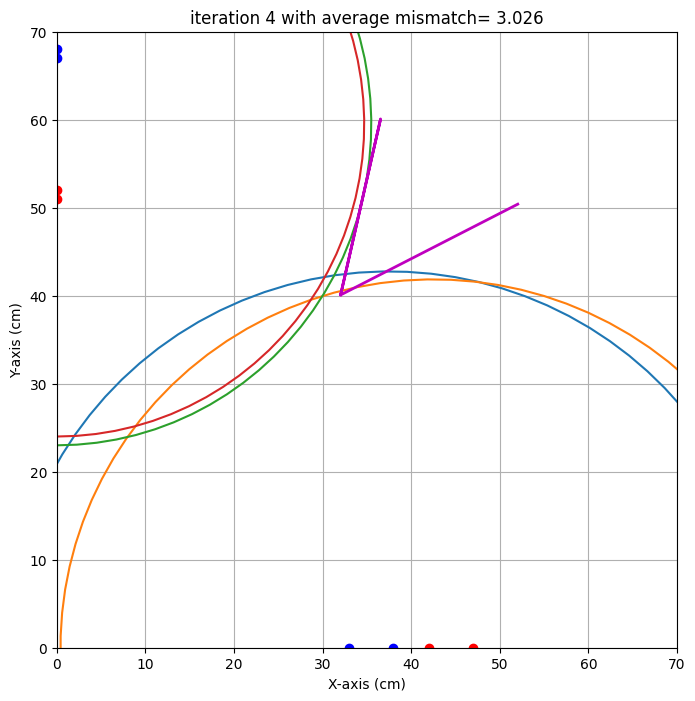

end iteration 4 with average mismatch= 3.026
end iteration 5 with average mismatch= 2.928


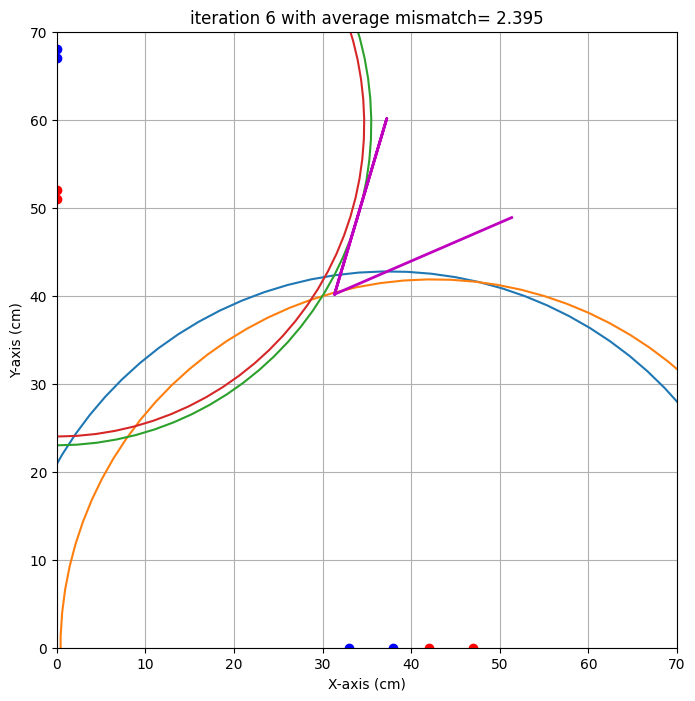

end iteration 6 with average mismatch= 2.395


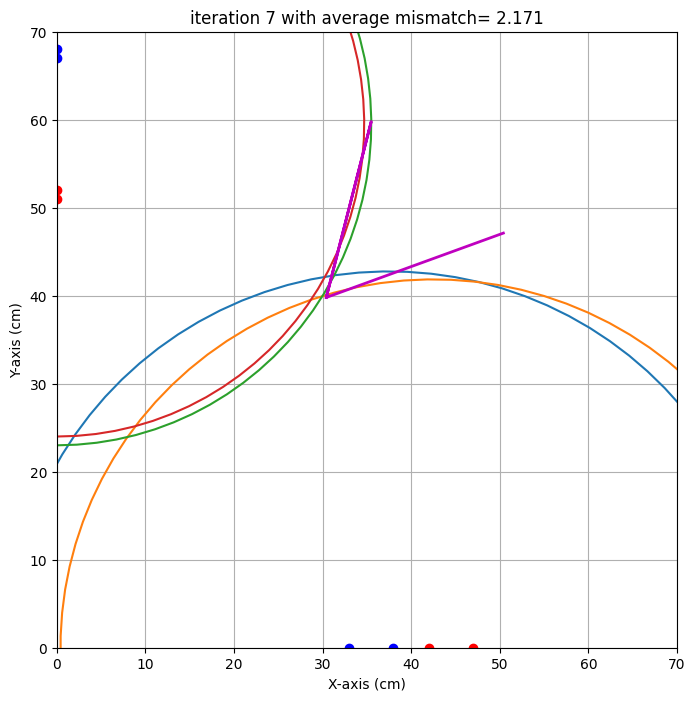

end iteration 7 with average mismatch= 2.171


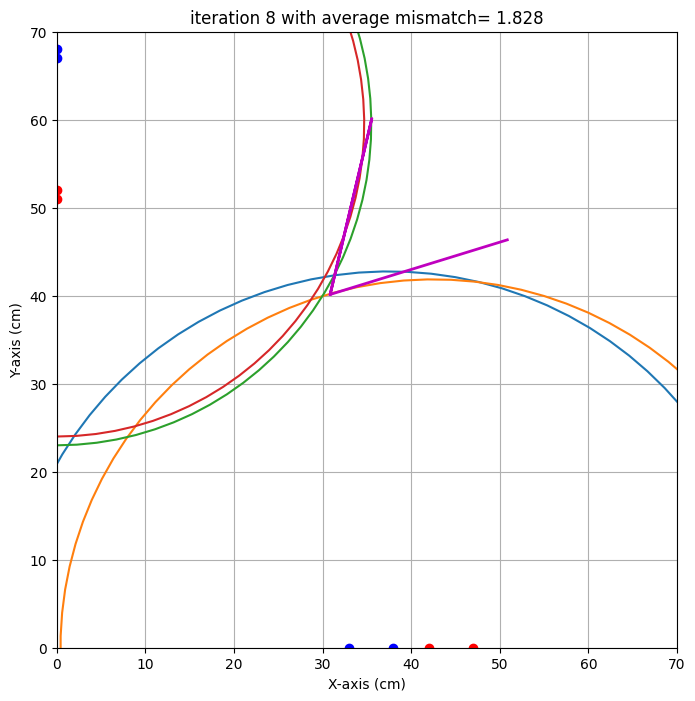

end iteration 8 with average mismatch= 1.828


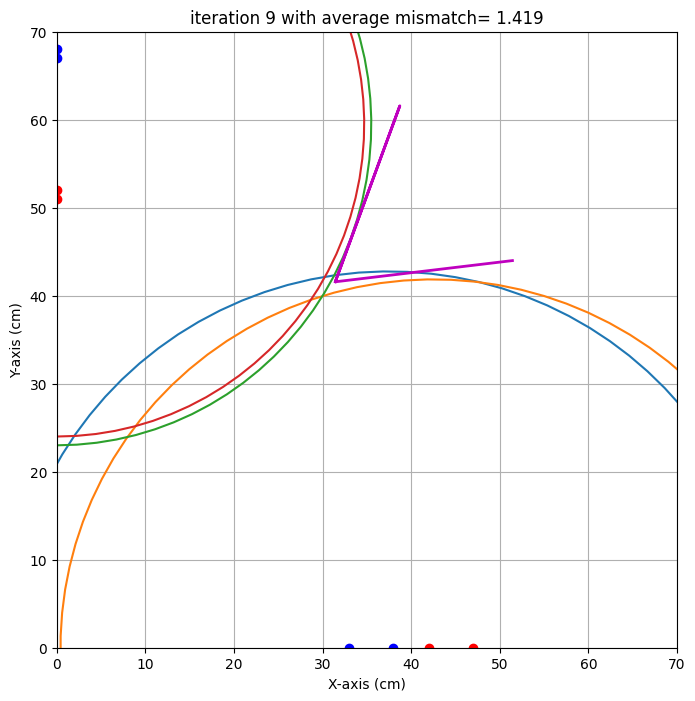

end iteration 9 with average mismatch= 1.419


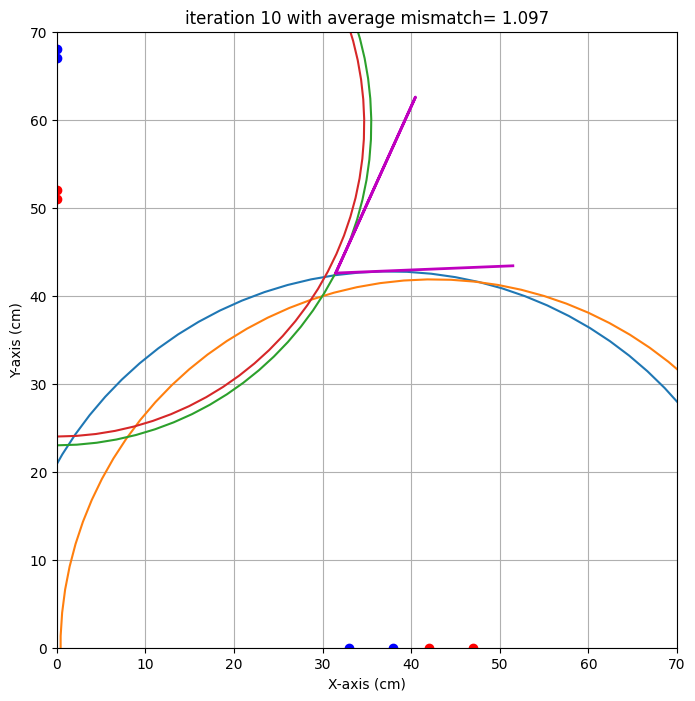

end iteration 10 with average mismatch= 1.097
end iteration 11 with average mismatch= 1.091
end iteration 12 with average mismatch= 1.090
end iteration 13 with average mismatch= 1.069
end iteration 14 with average mismatch= 0.969


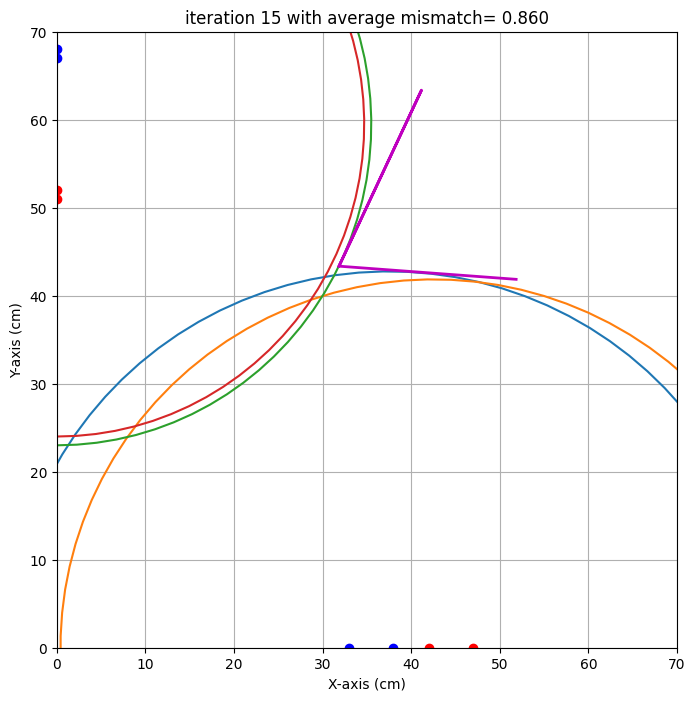

end iteration 15 with average mismatch= 0.860
end iteration 16 with average mismatch= 0.792


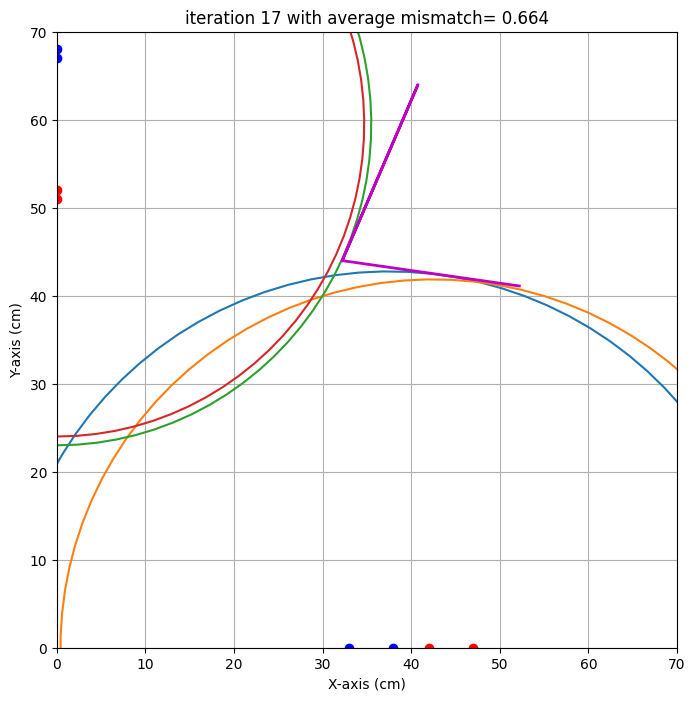

end iteration 17 with average mismatch= 0.664
end iteration 18 with average mismatch= 0.626
end iteration 19 with average mismatch= 0.625
end iteration 20 with average mismatch= 0.625
end iteration 21 with average mismatch= 0.625
end iteration 22 with average mismatch= 0.625
end iteration 23 with average mismatch= 0.625
end iteration 24 with average mismatch= 0.625
end iteration 25 with average mismatch= 0.597
end iteration 26 with average mismatch= 0.561
end iteration 27 with average mismatch= 0.561
end iteration 28 with average mismatch= 0.561
end iteration 29 with average mismatch= 0.560
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.537
###############################################################################
end of iteration  30
Best alpha=  -9.95 with uncertainty=   4.04
Best beta =  20.96 with uncertainty=  13.80
Best x0   =  32.35 with uncertainty=   1.53
Best y0   =  4

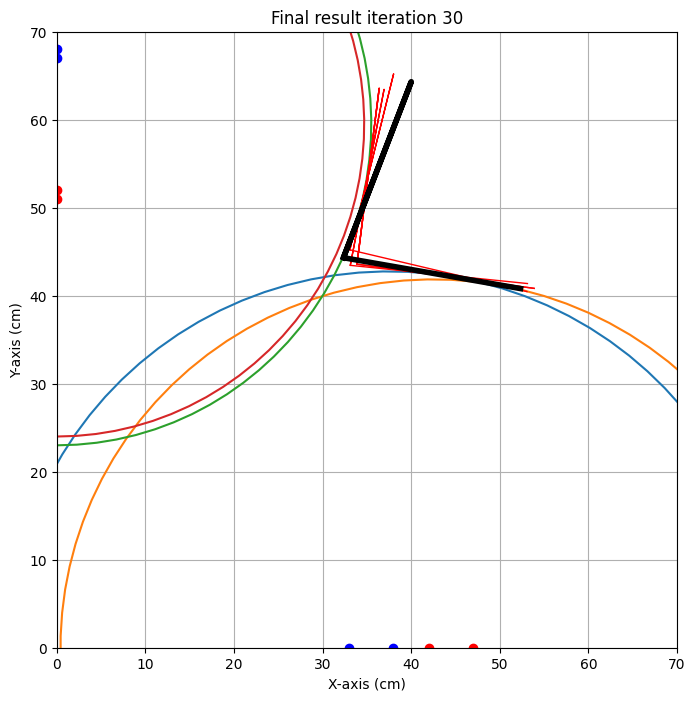

{'alpha': np.float64(-9.951237475909826), 'alpha_eps': np.float64(4.042907767155248), 'beta': np.float64(20.956380188260738), 'beta_eps': np.float64(13.797563368163742), 'x0': np.float64(32.34825770114729), 'x0_eps': np.float64(1.5300870726918916), 'y0': np.float64(44.319869278781724), 'y0_eps': np.float64(0.8962847655929806)}
Justin
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  20   0  30   0  86.7
1  25   0  35   0  85.0
2   0  52   0  62  66.0
3   0  57   0  67  66.0


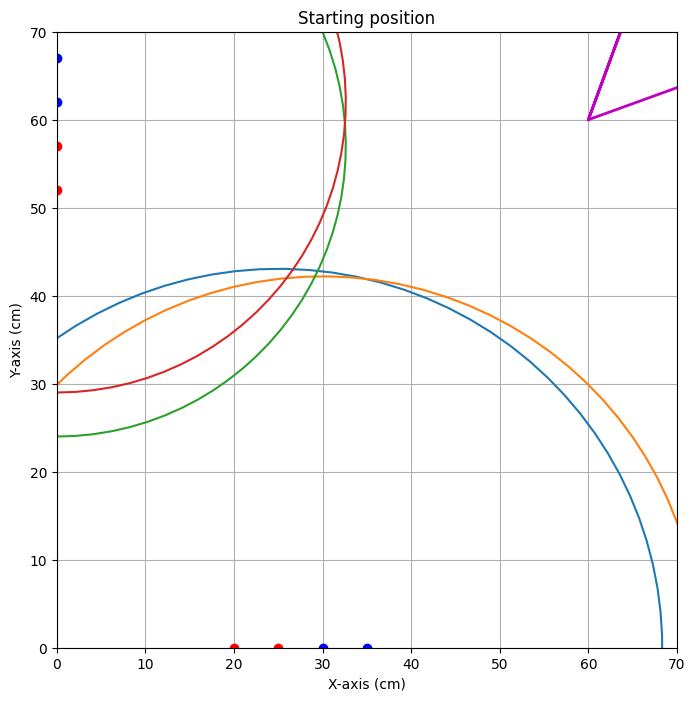


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=57.915


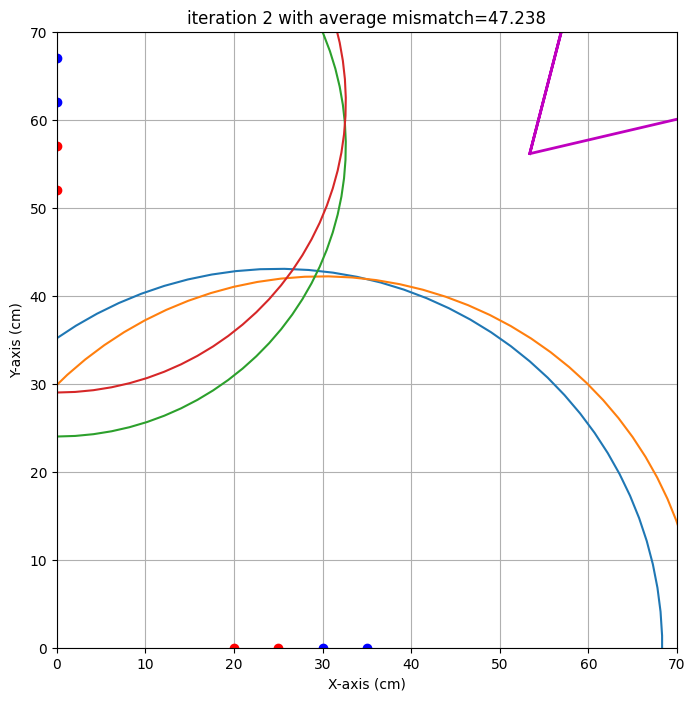

end iteration 2 with average mismatch=47.238


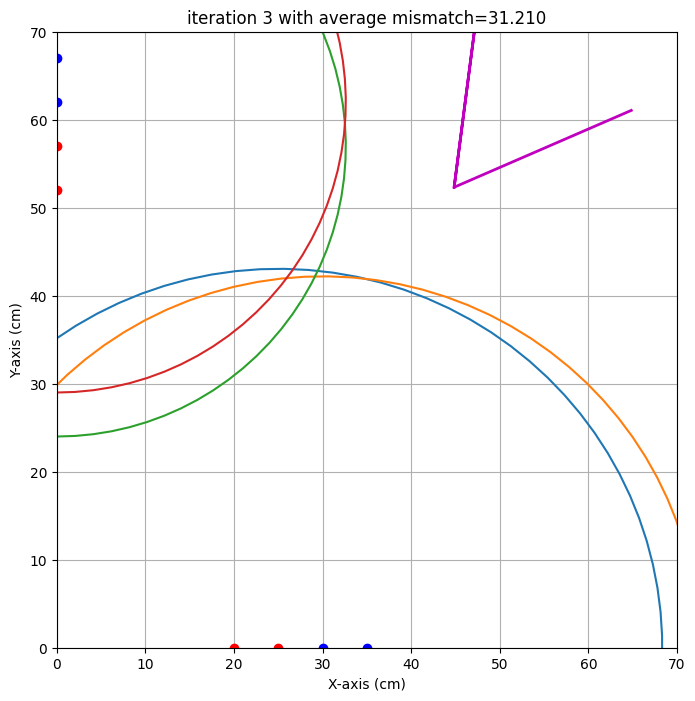

end iteration 3 with average mismatch=31.210


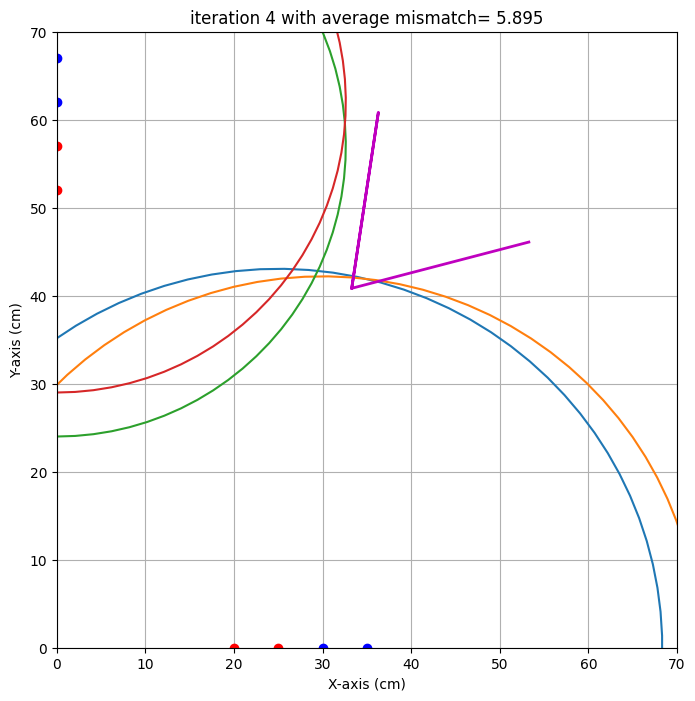

end iteration 4 with average mismatch= 5.895


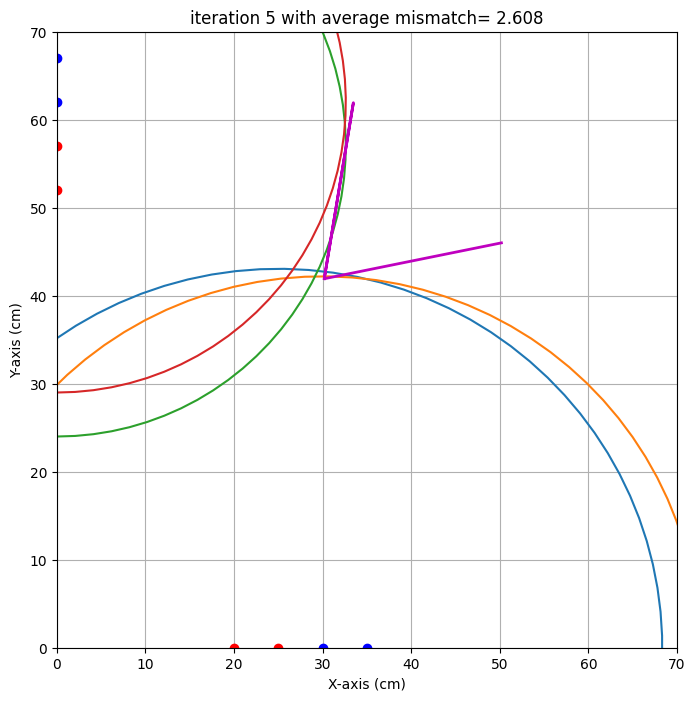

end iteration 5 with average mismatch= 2.608


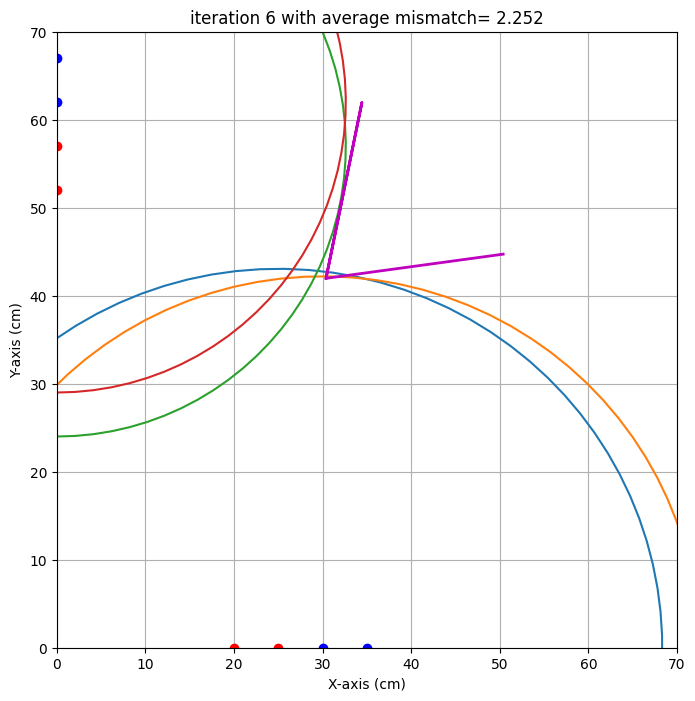

end iteration 6 with average mismatch= 2.252


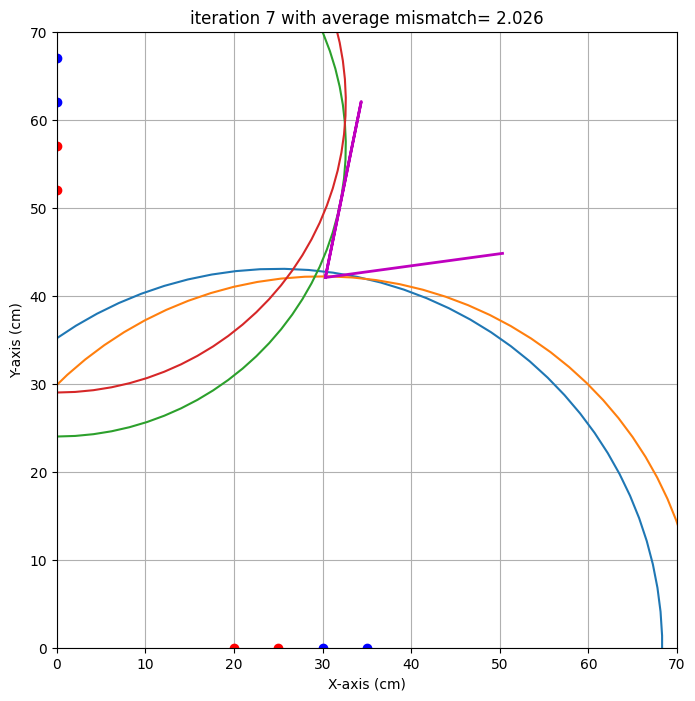

end iteration 7 with average mismatch= 2.026


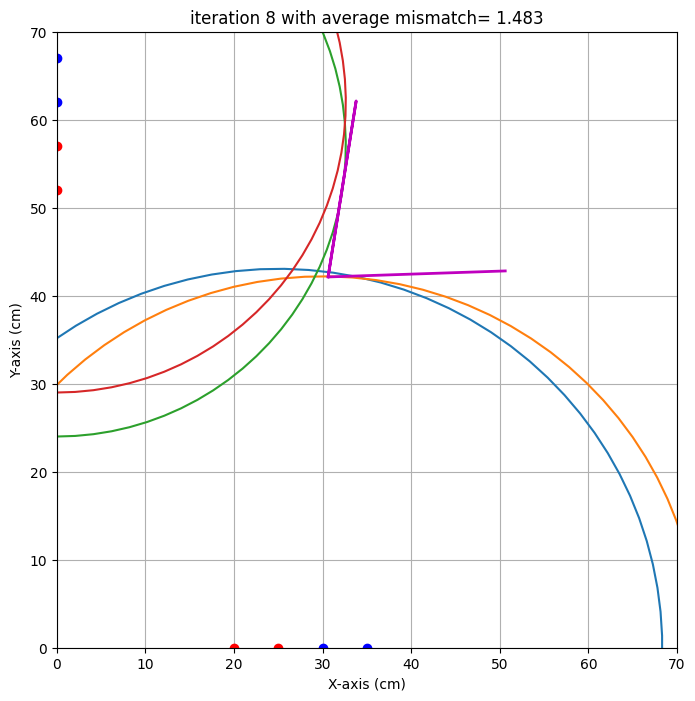

end iteration 8 with average mismatch= 1.483
end iteration 9 with average mismatch= 1.357


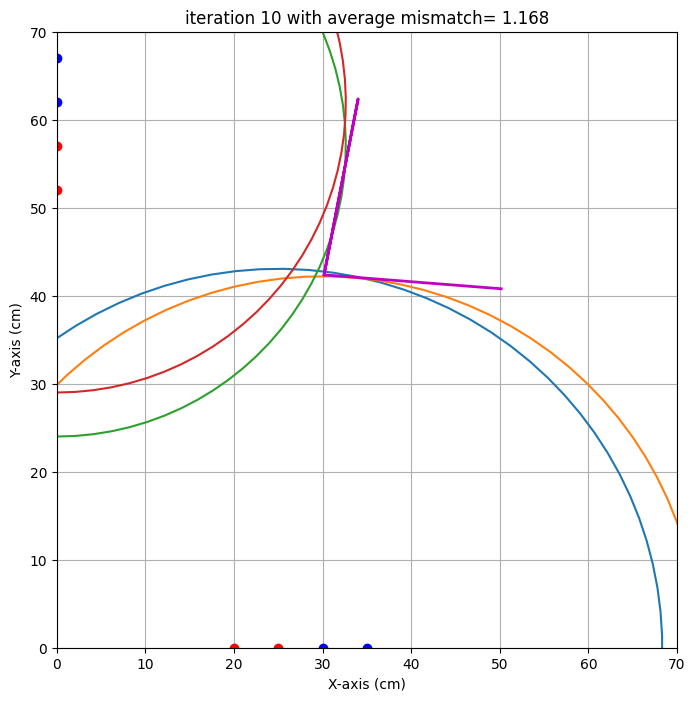

end iteration 10 with average mismatch= 1.168


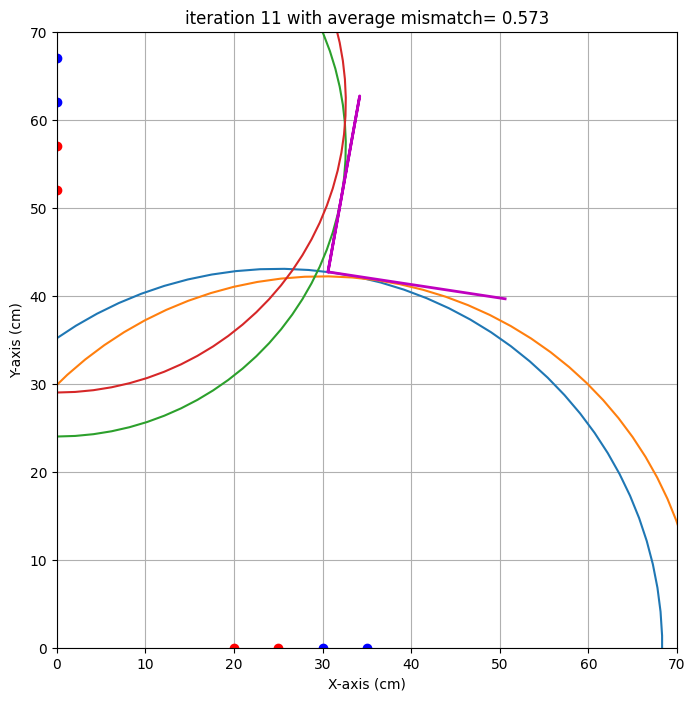

end iteration 11 with average mismatch= 0.573
end iteration 12 with average mismatch= 0.569
end iteration 13 with average mismatch= 0.569
end iteration 14 with average mismatch= 0.569
end iteration 15 with average mismatch= 0.569
end iteration 16 with average mismatch= 0.569
end iteration 17 with average mismatch= 0.569
end iteration 18 with average mismatch= 0.569


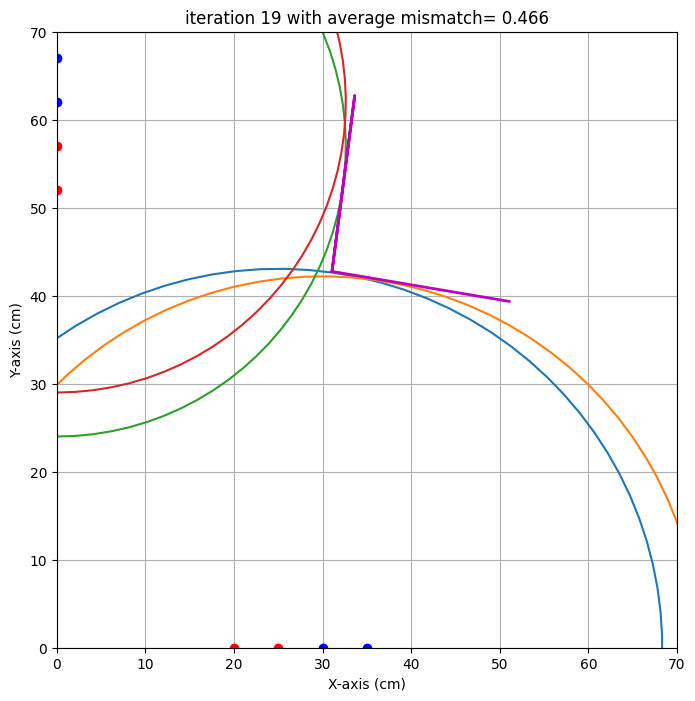

end iteration 19 with average mismatch= 0.466
end iteration 20 with average mismatch= 0.465
end iteration 21 with average mismatch= 0.465
end iteration 22 with average mismatch= 0.464
end iteration 23 with average mismatch= 0.464
end iteration 24 with average mismatch= 0.464
end iteration 25 with average mismatch= 0.422
end iteration 26 with average mismatch= 0.397
end iteration 27 with average mismatch= 0.379
end iteration 28 with average mismatch= 0.373
end iteration 29 with average mismatch= 0.373
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.373
###############################################################################
end of iteration  30
Best alpha=  -9.66 with uncertainty=  11.04
Best beta =   5.48 with uncertainty=   4.05
Best x0   =  31.36 with uncertainty=   0.99
Best y0   =  42.60 with uncertainty=   1.51
##############################################################

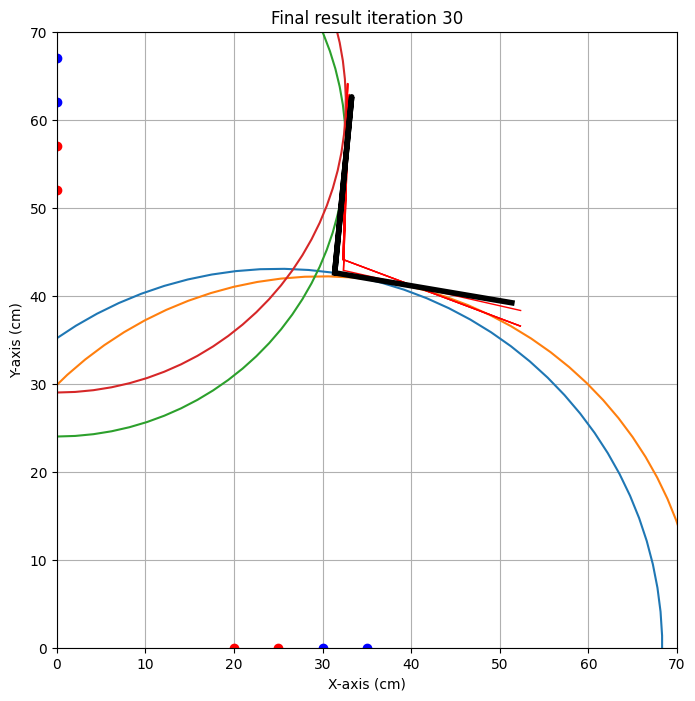

{'alpha': np.float64(-9.660180566853386), 'alpha_eps': np.float64(11.038082384677976), 'beta': np.float64(5.480145664032154), 'beta_eps': np.float64(4.050105141494295), 'x0': np.float64(31.363766162815924), 'x0_eps': np.float64(0.9916232810908703), 'y0': np.float64(42.602410387903696), 'y0_eps': np.float64(1.5061935987696558)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Tim 
x0 target is : 29.0. Gevonden waarde: 37.9 cm met een standaardafwijking van 5.0 cm 
y0 target is : 43.0. Gevonden waarde: 43.6 cm met een standaardafwijking van 0.2 cm 
alpha target is : 0.0. Gevonden waarde: -11.8 graden met een standaardafwijking van 5.9 graad 
beta target is : 29.0. Gevonden waarde: -14.1 graden met een standaardafwijking van 14.9 graad 

Laura 
x0 target is : 29.0. Gevonden waarde: 32.3 cm met een standaardafwijking van 1.5 cm 
y0 target is : 43.0. Gevonden waarde: 44.3 cm met een standaardafwijking van 0.9 cm 
alpha target is : 0.0. Gevonden waarde: -10.0 graden met een standaardafwijking van 4.0 graad 
beta target is : 29.0. Gevonden waarde: 21.0 graden met een standaardafwijking van 13.8 graad 

Justin 
x0 target is : 29.0. Gevonden waarde: 31.4 cm met een standaardafwijking van 1.0 cm 
y0 target is : 43.0. Gevonden waarde: 42.6 cm met een standaardafwijking van 1.5 cm 
alpha target is : 0.0. Gevonden waarde: -9.7 graden met een standaardafwijking van 11.0

## Opdracht 8: Iteratie1 15:00.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Iteratie 1: ![Alt](AlgoritmeFinal.jpg)


In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  35   0  45   0  119.0
1  40   0  50   0  118.0
2   0  59   0  69   80.0
3   0  64   0  74   80.0
4   0  69   0  79   81.0
5  45   0  55   0  117.0


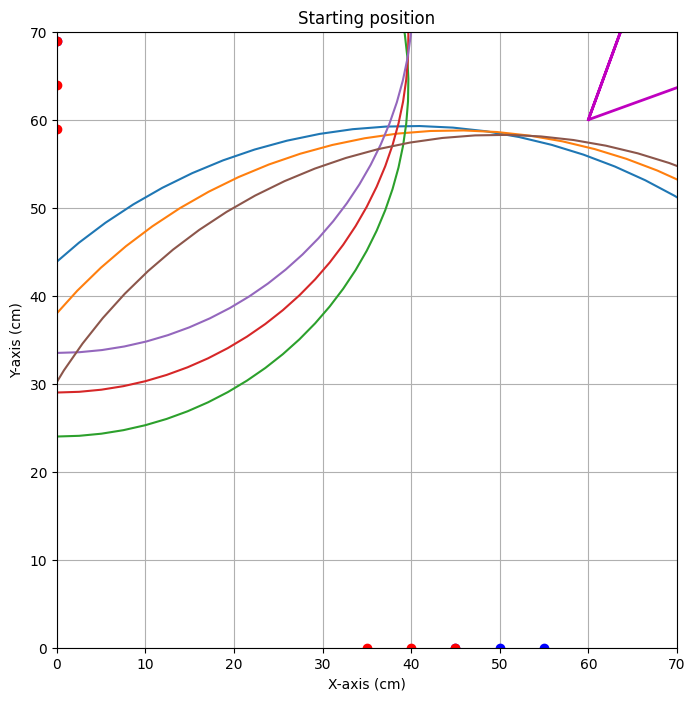


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=28.664


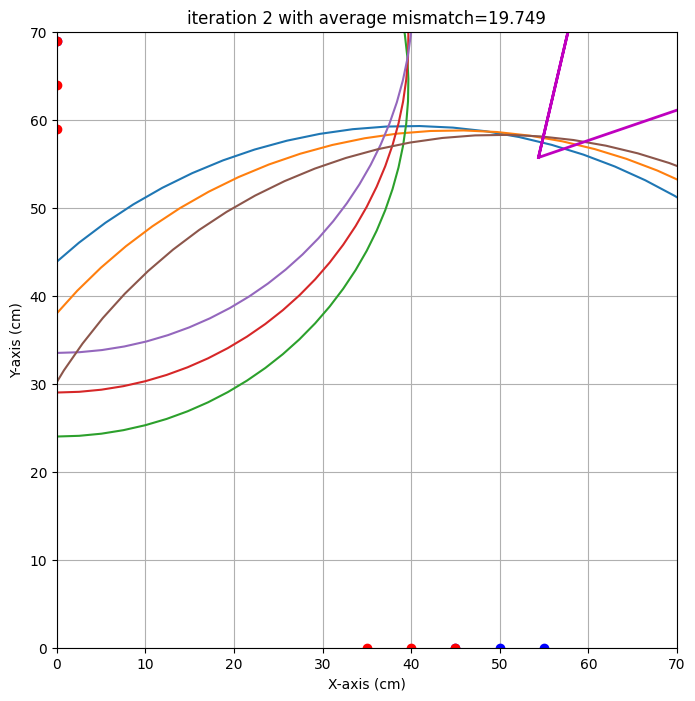

end iteration 2 with average mismatch=19.749


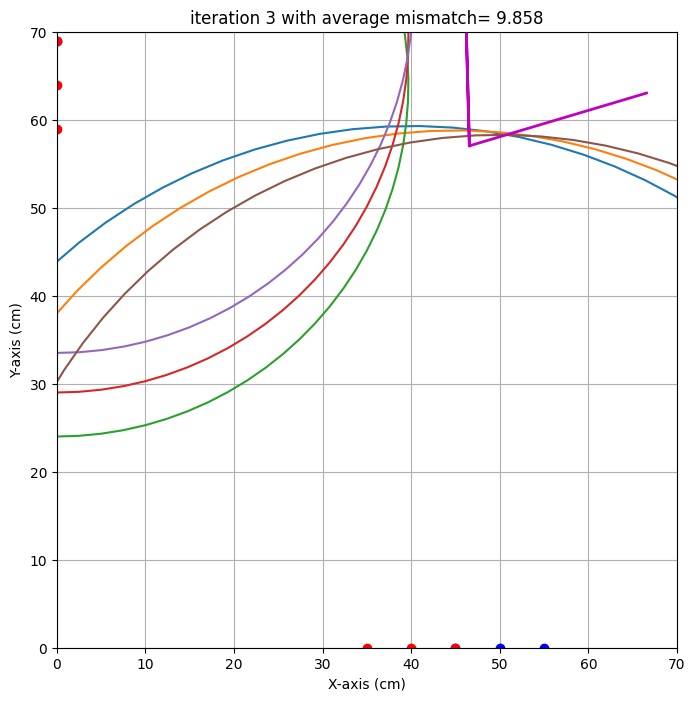

end iteration 3 with average mismatch= 9.858


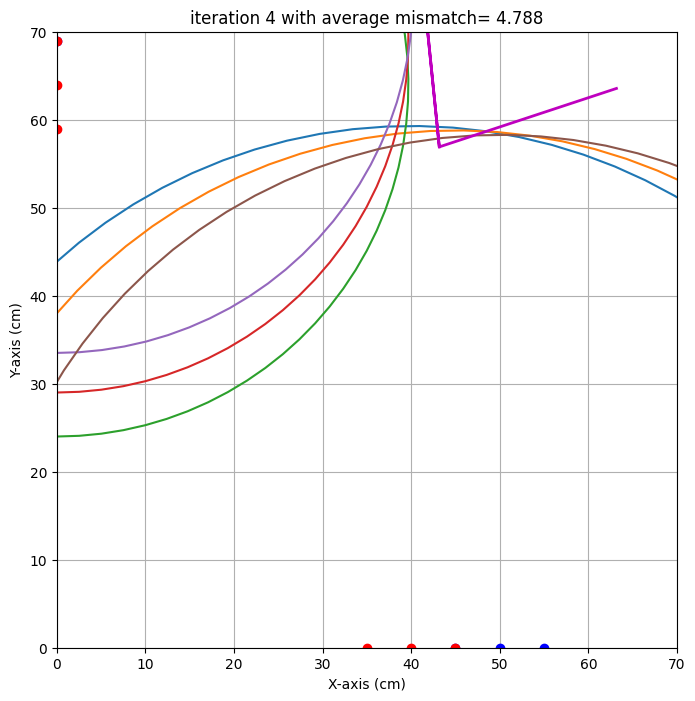

end iteration 4 with average mismatch= 4.788


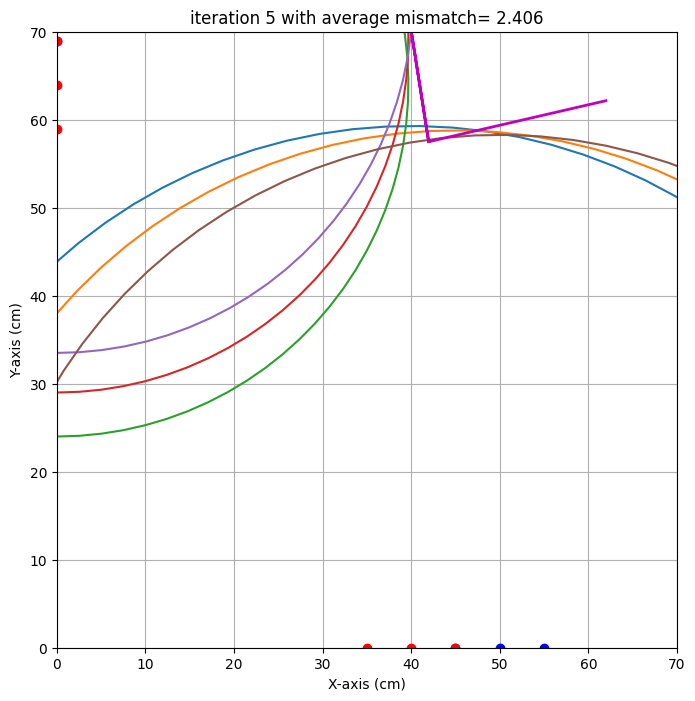

end iteration 5 with average mismatch= 2.406
end iteration 6 with average mismatch= 2.309


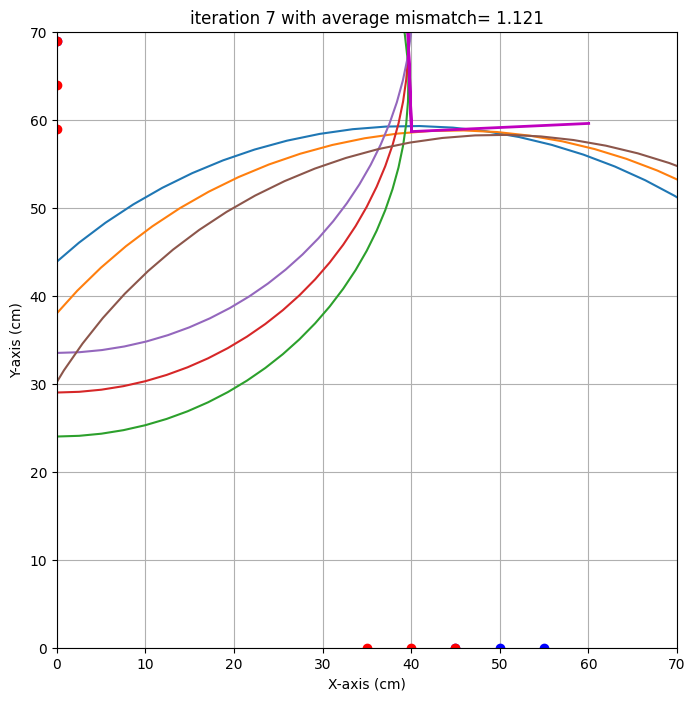

end iteration 7 with average mismatch= 1.121


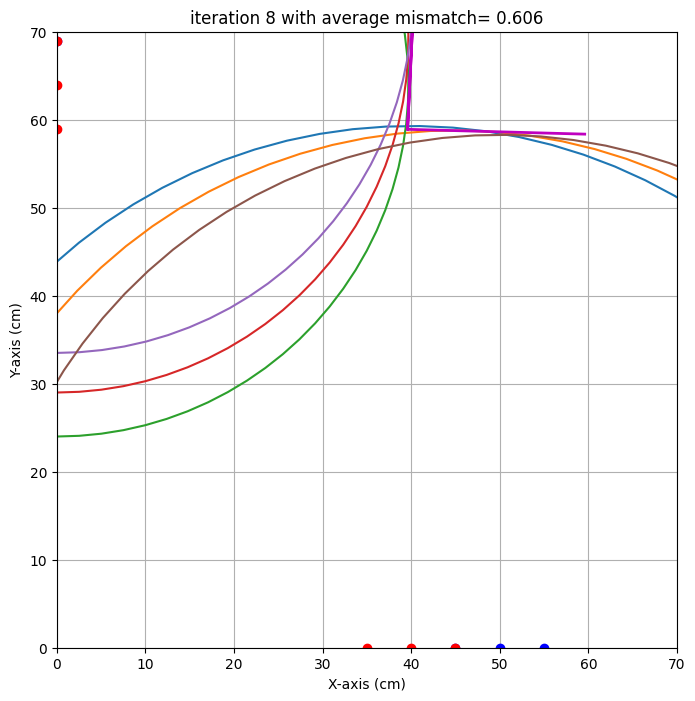

end iteration 8 with average mismatch= 0.606


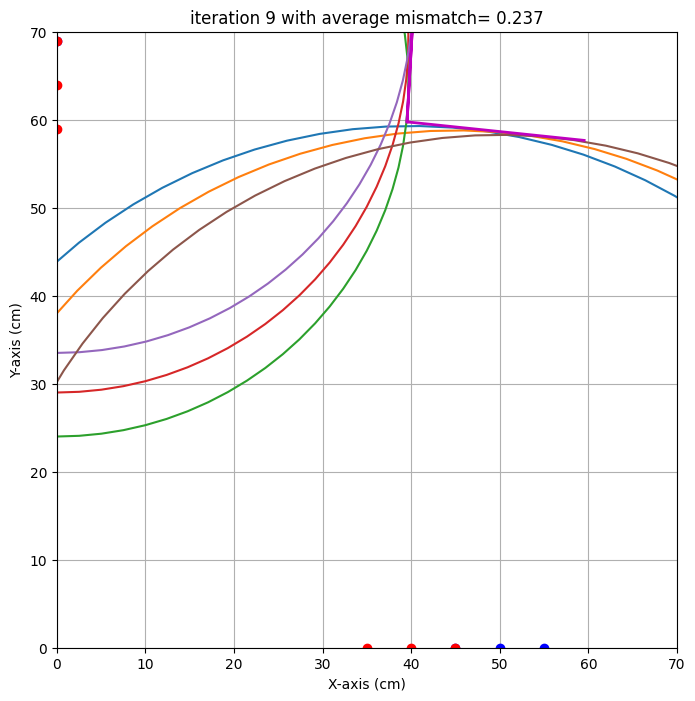

end iteration 9 with average mismatch= 0.237


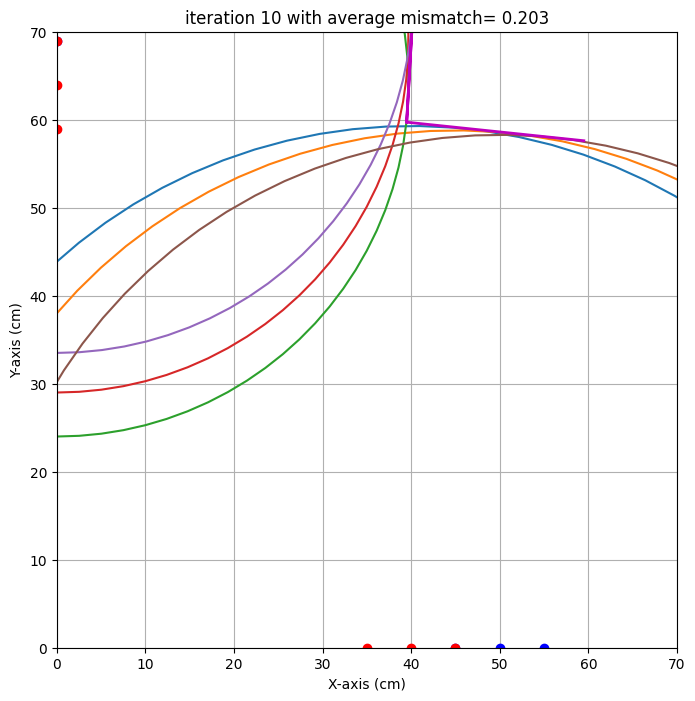

end iteration 10 with average mismatch= 0.203
end iteration 11 with average mismatch= 0.202
end iteration 12 with average mismatch= 0.202
end iteration 13 with average mismatch= 0.202
end iteration 14 with average mismatch= 0.202
end iteration 15 with average mismatch= 0.202
end iteration 16 with average mismatch= 0.202
end iteration 17 with average mismatch= 0.202
end iteration 18 with average mismatch= 0.202
end iteration 19 with average mismatch= 0.202
end iteration 20 with average mismatch= 0.202
end iteration 21 with average mismatch= 0.202
end iteration 22 with average mismatch= 0.202
end iteration 23 with average mismatch= 0.202
end iteration 24 with average mismatch= 0.202
end iteration 25 with average mismatch= 0.202
end iteration 26 with average mismatch= 0.202
end iteration 27 with average mismatch= 0.202
end iteration 28 with average mismatch= 0.202
end iteration 29 with average mismatch= 0.202
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

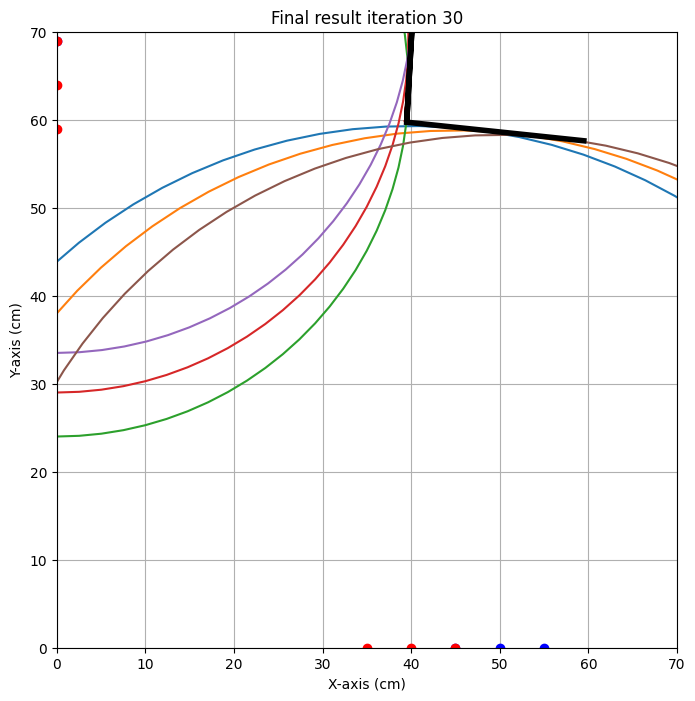

{'alpha': np.float64(-6.020862245837801), 'alpha_eps': np.float64(0.20550533529049275), 'beta': np.float64(3.208322706084048), 'beta_eps': np.float64(0.9154511421105243), 'x0': np.float64(39.49010166279636), 'x0_eps': np.float64(0.23334162260081825), 'y0': np.float64(59.71770247382237), 'y0_eps': np.float64(0.12437225332195112)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  45   0  73.5
1  37   0  47   0  71.8
2  33   0  43   0  72.0
3  39   0  49   0  73.0
4   0  46   0  56  66.5
5   0  44   0  54  67.0
6   0  48   0  58  68.0
7   0  50   0  60  69.2


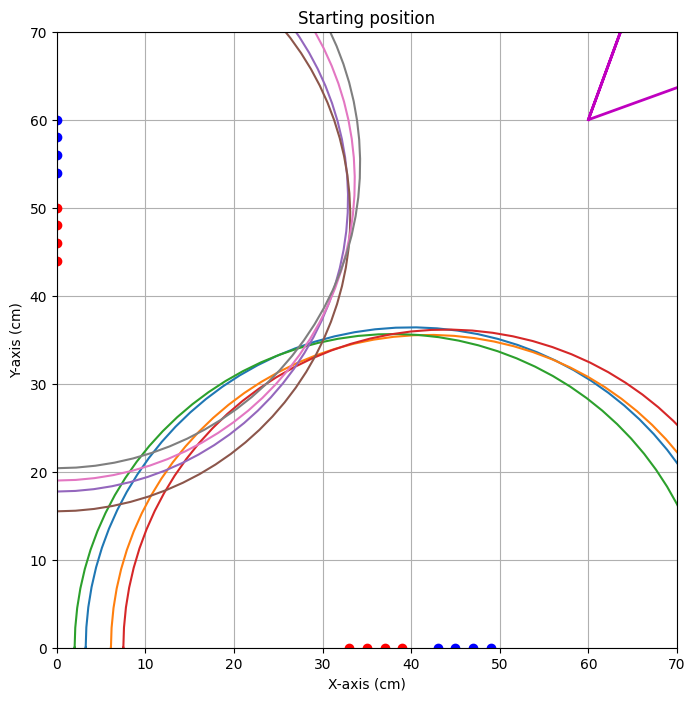


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=59.771


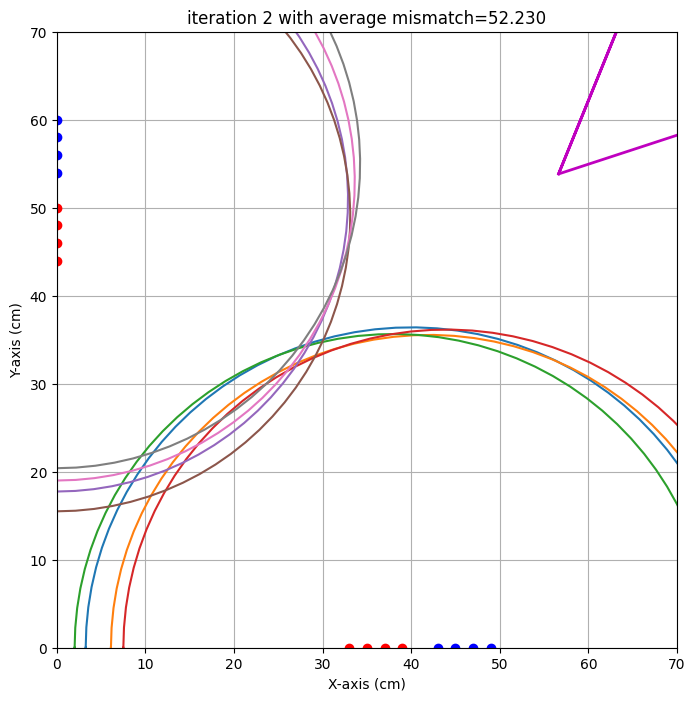

end iteration 2 with average mismatch=52.230


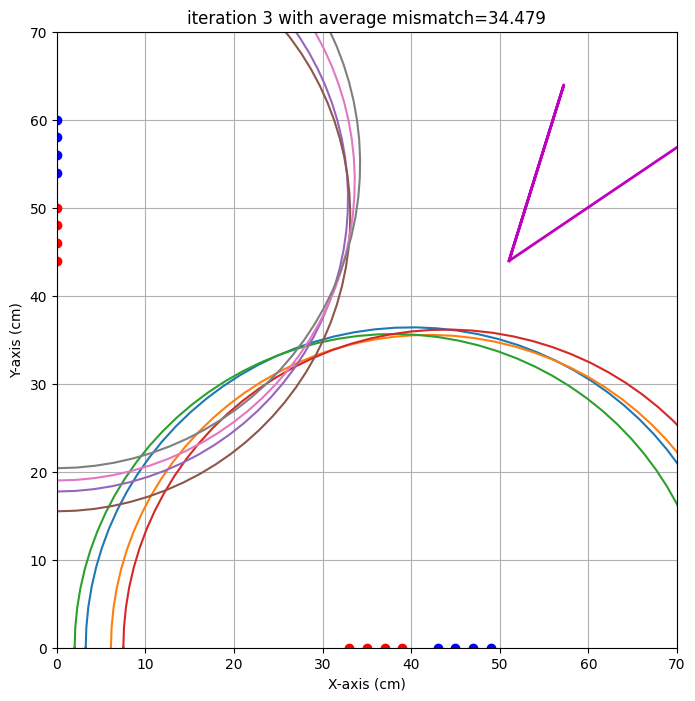

end iteration 3 with average mismatch=34.479


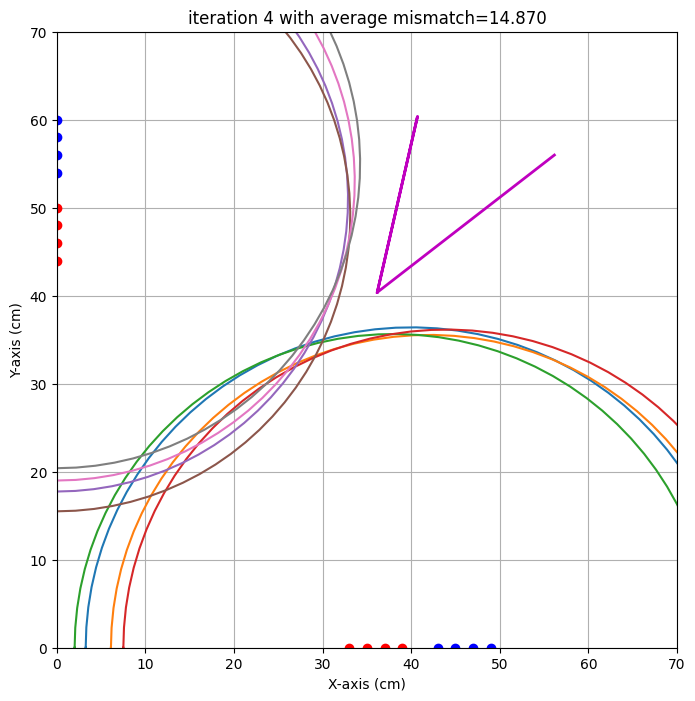

end iteration 4 with average mismatch=14.870


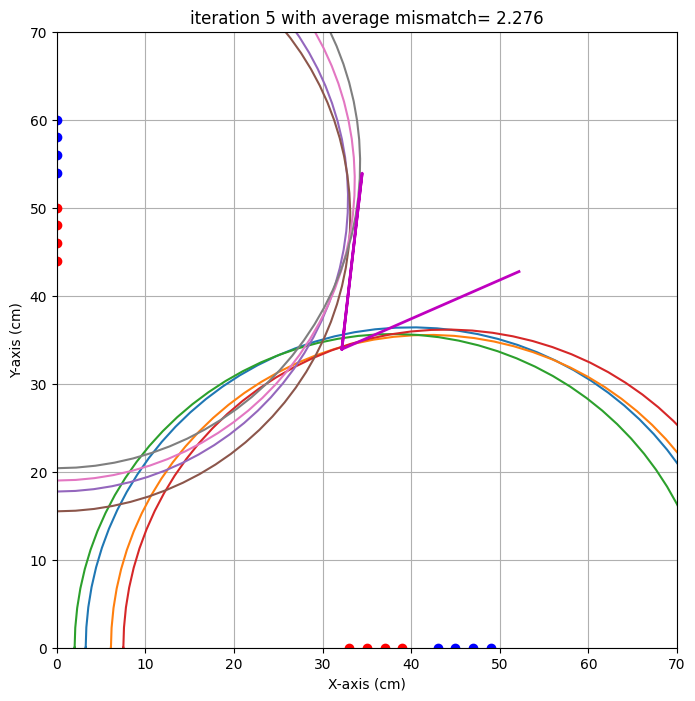

end iteration 5 with average mismatch= 2.276


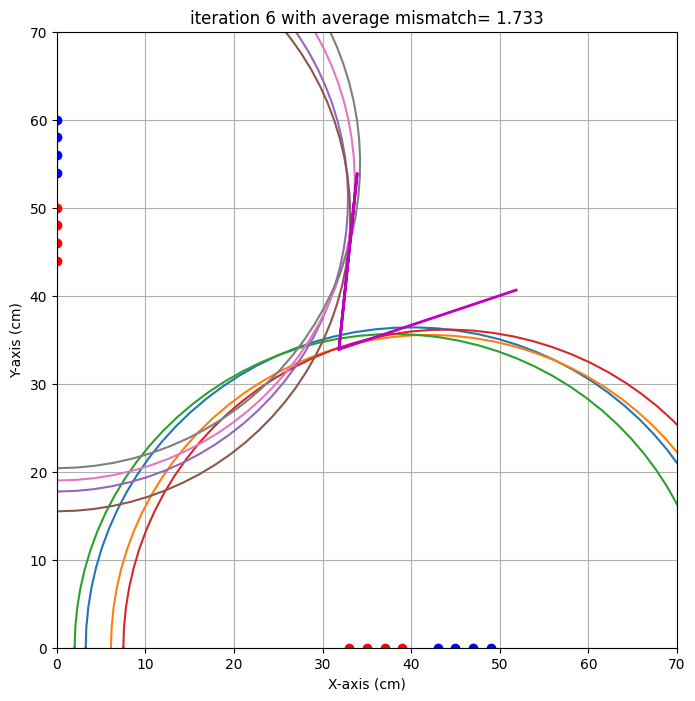

end iteration 6 with average mismatch= 1.733


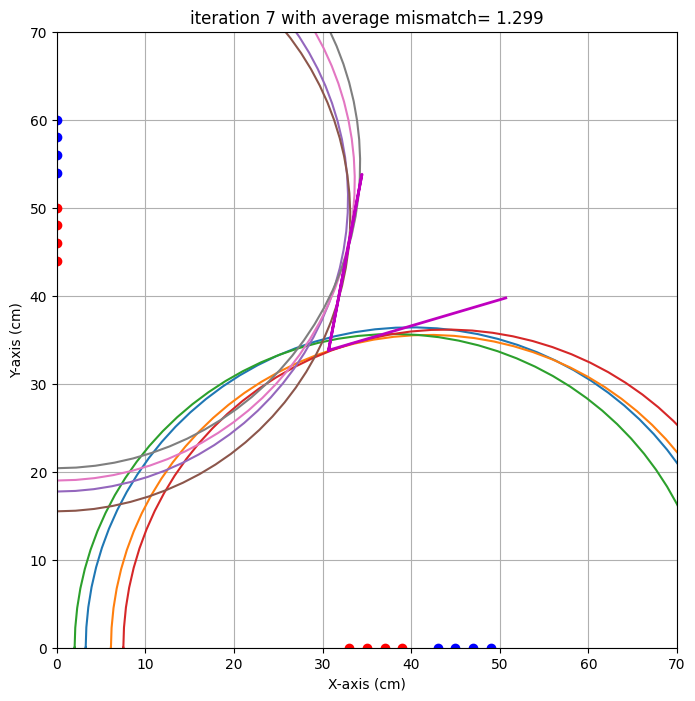

end iteration 7 with average mismatch= 1.299


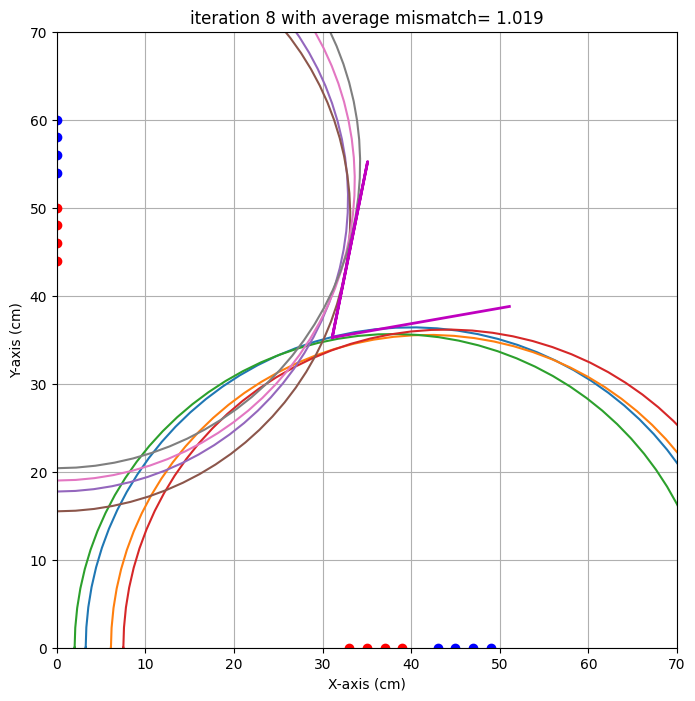

end iteration 8 with average mismatch= 1.019
end iteration 9 with average mismatch= 0.947
end iteration 10 with average mismatch= 0.872
end iteration 11 with average mismatch= 0.820
end iteration 12 with average mismatch= 0.815
end iteration 13 with average mismatch= 0.813
end iteration 14 with average mismatch= 0.813
end iteration 15 with average mismatch= 0.813
end iteration 16 with average mismatch= 0.813
end iteration 17 with average mismatch= 0.813
end iteration 18 with average mismatch= 0.813
end iteration 19 with average mismatch= 0.775
end iteration 20 with average mismatch= 0.759
end iteration 21 with average mismatch= 0.734
end iteration 22 with average mismatch= 0.734
end iteration 23 with average mismatch= 0.734
end iteration 24 with average mismatch= 0.734
end iteration 25 with average mismatch= 0.734
end iteration 26 with average mismatch= 0.734
end iteration 27 with average mismatch= 0.734
end iteration 28 with average mismatch= 0.734
end iteration 29 with average mismat

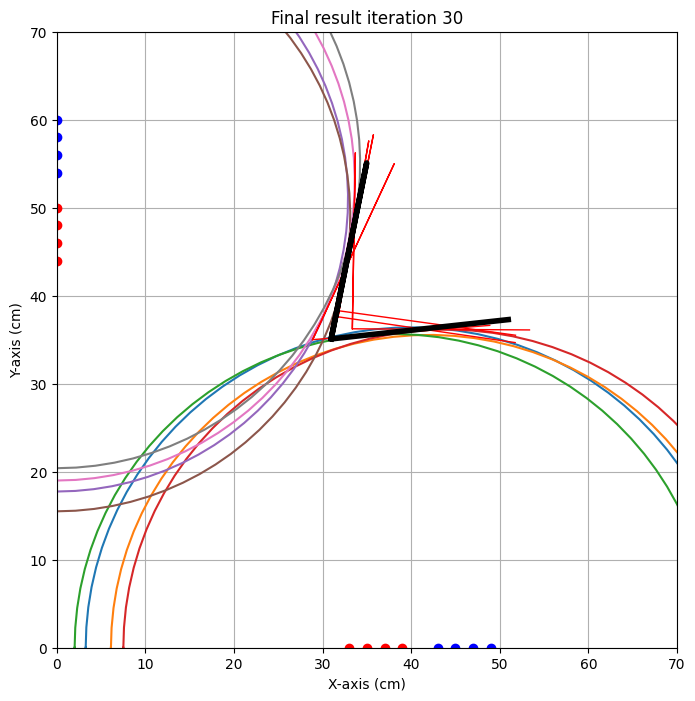

{'alpha': np.float64(6.2656295655437555), 'alpha_eps': np.float64(14.596515694124587), 'beta': np.float64(11.341203032930483), 'beta_eps': np.float64(13.40457079191653), 'x0': np.float64(30.960757023357218), 'x0_eps': np.float64(2.394176639919621), 'y0': np.float64(35.090603493456356), 'y0_eps': np.float64(3.2054826862742303)}
locatie 1 
x0 target is : 38.0. Gevonden waarde: 39.5 cm met een standaardafwijking van 0.2 cm 
y0 target is : 57.0. Gevonden waarde: 59.7 cm met een standaardafwijking van 0.1 cm 
alpha target is : 20.0. Gevonden waarde: -6.0 graden met een standaardafwijking van 0.2 graad 
beta target is : 19.0. Gevonden waarde: 3.2 graden met een standaardafwijking van 0.9 graad 

locatie 2 
x0 target is : 34.0. Gevonden waarde: 31.0 cm met een standaardafwijking van 2.4 cm 
y0 target is : 35.0. Gevonden waarde: 35.1 cm met een standaardafwijking van 3.2 cm 
alpha target is : 20.0. Gevonden waarde: 6.3 graden met een standaardafwijking van 14.6 graad 
beta target is : 15.0. Ge

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 38,
                    'y0': 57,
                    'alpha' : 20,
                    'beta' : 19},
           'locatie 2':{'x0':34,
                    'y0':35,
                    'alpha' :20,
                    'beta' :15 }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [35, 0, 45, 0, 119.0],
    [40, 0, 50, 0, 118.0],
    [0, 59, 0, 69, 80],
    [0, 64, 0, 74, 80],
    [0, 69, 0, 79, 81],
    [45, 0, 55, 0, 117]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [35, 0, 45, 0, 73.5],
    [37, 0, 47, 0, 71.8],
    [33, 0, 43, 0, 72],
    [39, 0, 49, 0, 73],
    [0, 46, 0, 56, 66.5],
    [0, 44, 0, 54, 67.0],
    [0, 48, 0, 58, 68],
    [0, 50, 0, 60, 69.2],
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  35   0  45   0  64.5
1  40   0  50   0  65.9
2  45   0  55   0  67.6
3  50   0  60   0  71.8
4  55   0  65   0  74.5
5   0  42   0  52  52.6
6   0  47   0  57  53.2
7   0  52   0  62  53.6
8   0  37   0  47  52.2
9   0  32   0  42  50.9


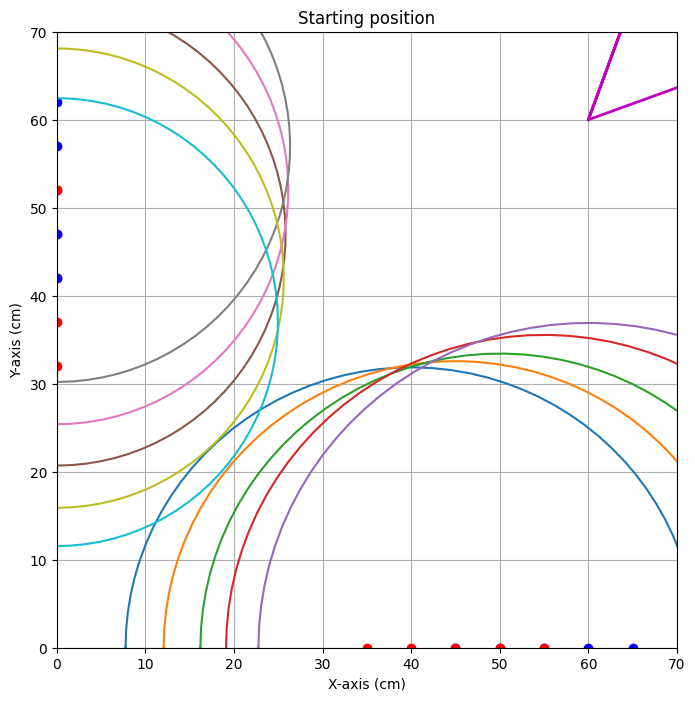


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=69.016


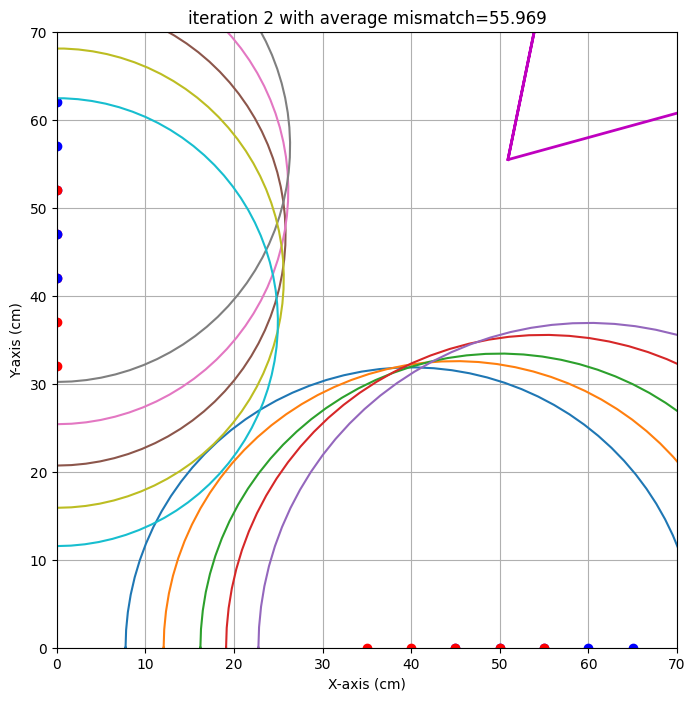

end iteration 2 with average mismatch=55.969


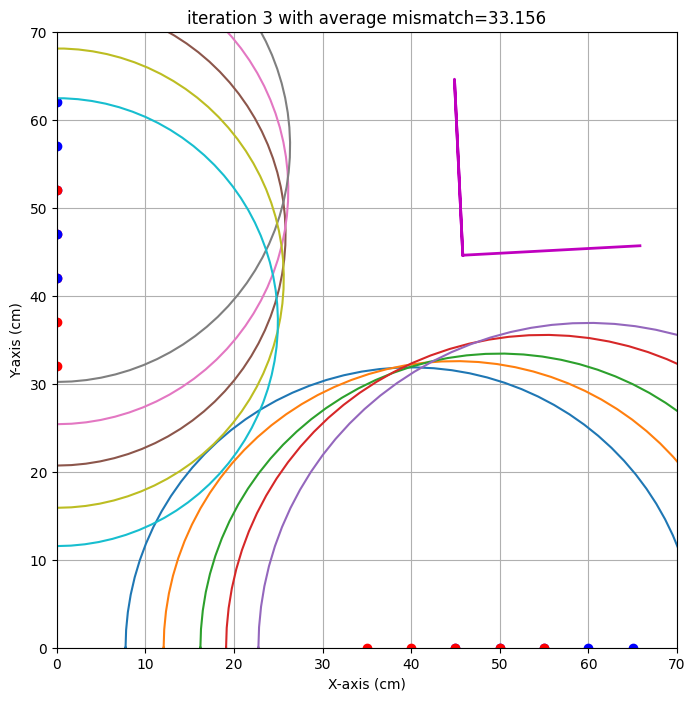

end iteration 3 with average mismatch=33.156


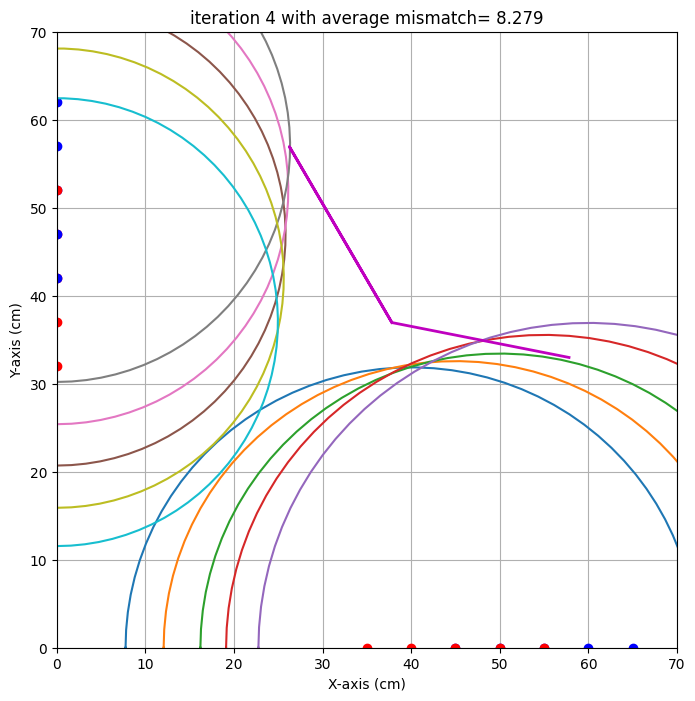

end iteration 4 with average mismatch= 8.279


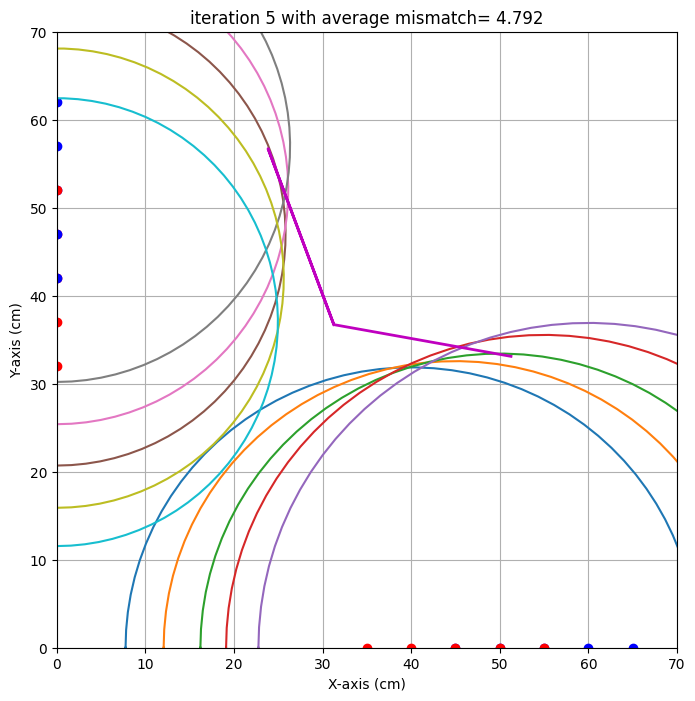

end iteration 5 with average mismatch= 4.792


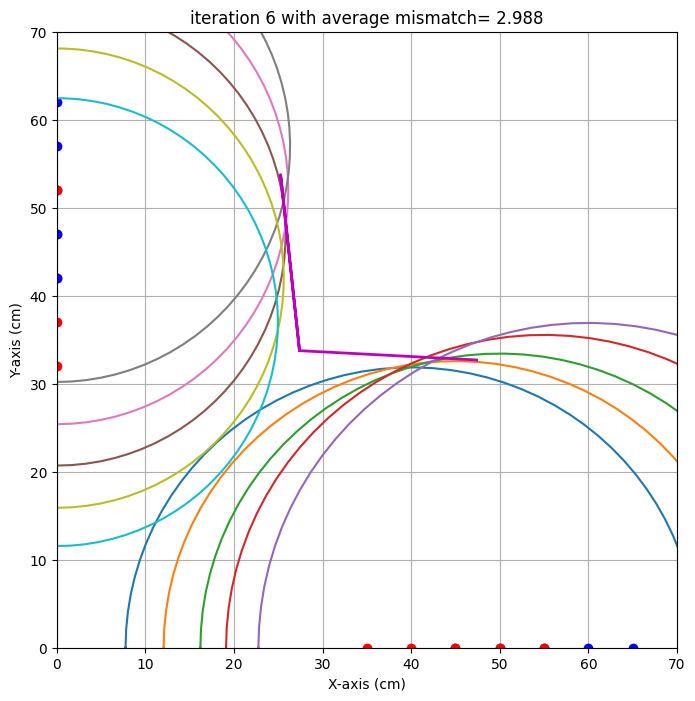

end iteration 6 with average mismatch= 2.988


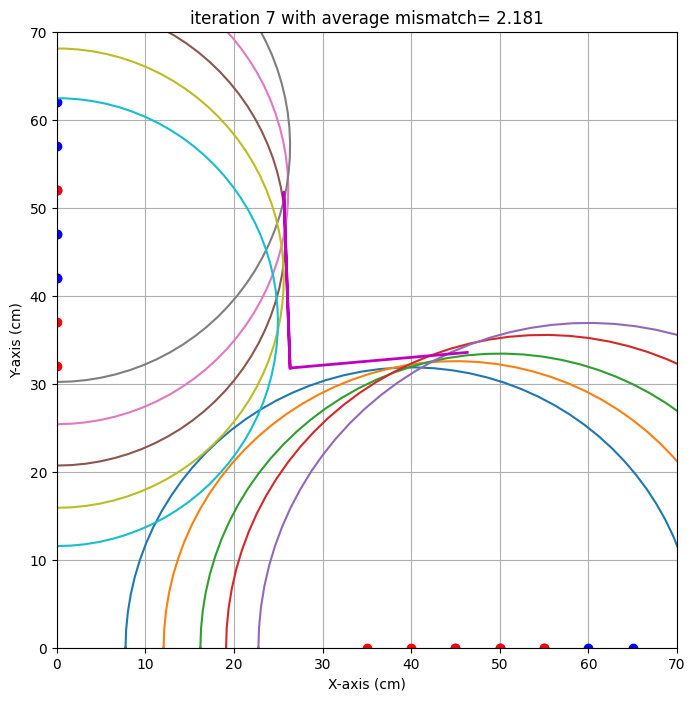

end iteration 7 with average mismatch= 2.181
end iteration 8 with average mismatch= 2.129


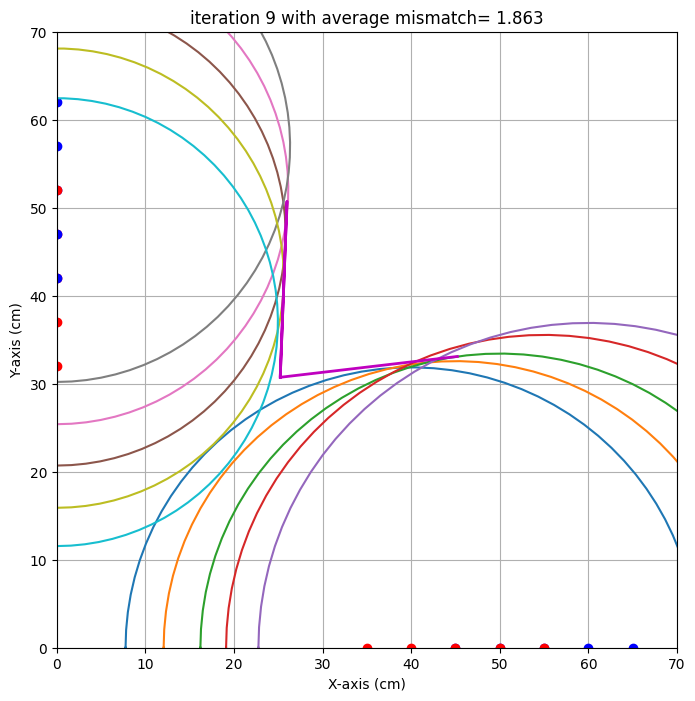

end iteration 9 with average mismatch= 1.863
end iteration 10 with average mismatch= 1.862
end iteration 11 with average mismatch= 1.862
end iteration 12 with average mismatch= 1.832
end iteration 13 with average mismatch= 1.829
end iteration 14 with average mismatch= 1.823
end iteration 15 with average mismatch= 1.821
end iteration 16 with average mismatch= 1.776
end iteration 17 with average mismatch= 1.766
end iteration 18 with average mismatch= 1.764
end iteration 19 with average mismatch= 1.763
end iteration 20 with average mismatch= 1.763
end iteration 21 with average mismatch= 1.763
end iteration 22 with average mismatch= 1.763
end iteration 23 with average mismatch= 1.763
end iteration 24 with average mismatch= 1.763
end iteration 25 with average mismatch= 1.735
end iteration 26 with average mismatch= 1.734
end iteration 27 with average mismatch= 1.697
end iteration 28 with average mismatch= 1.697
end iteration 29 with average mismatch= 1.697
Last iteration, also determine unce

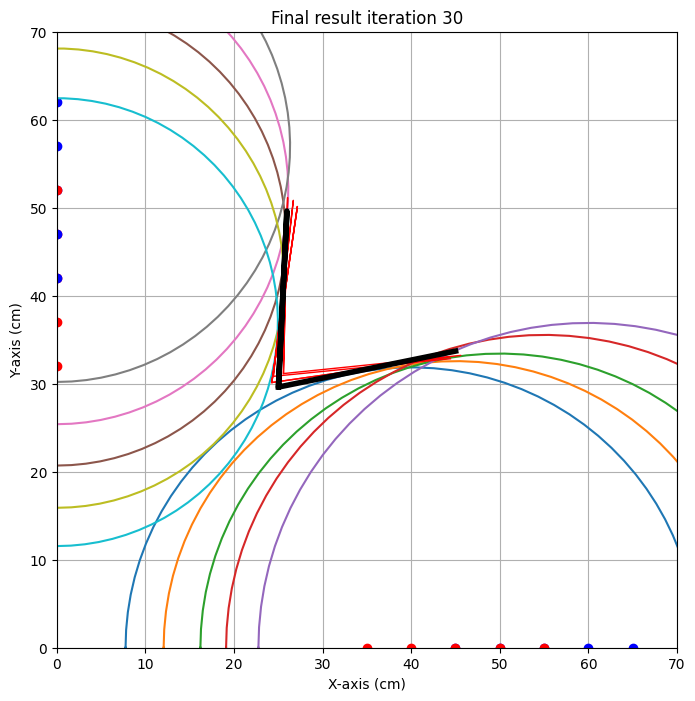

{'alpha': np.float64(11.556417387201058), 'alpha_eps': np.float64(5.85082828567428), 'beta': np.float64(2.7435403068857003), 'beta_eps': np.float64(5.480346698257009), 'x0': np.float64(25.010970916693562), 'x0_eps': np.float64(0.749882482410758), 'y0': np.float64(29.621157584145475), 'y0_eps': np.float64(1.534062706446175)}
locatie 1 
x0 target is : 27.0. Gevonden waarde: 25.0 cm met een standaardafwijking van 0.7 cm 
y0 target is : 30.0. Gevonden waarde: 29.6 cm met een standaardafwijking van 1.5 cm 
alpha target is : 14.0. Gevonden waarde: 11.6 graden met een standaardafwijking van 5.9 graad 
beta target is : 5.0. Gevonden waarde: 2.7 graden met een standaardafwijking van 5.5 graad 



In [12]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 27,
                    'y0': 30,
                    'alpha' : 14,
                    'beta' : 5}, }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [35, 0, 45, 0, 64.5],
    [40, 0, 50, 0, 65.9],
    [45, 0, 55, 0, 67.6],
    [50, 0, 60, 0, 71.8],
    [55, 0, 65, 0, 74.5],
    [0, 42, 0, 52, 52.6],
    [0, 47, 0, 57, 53.2],
    [0, 52, 0, 62, 53.6],
    [0, 37, 0, 47, 52.2],
    [0, 32, 0, 42, 50.9],
    ])}                   
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
    xs  ys  xr  yr     R
0   25   0  35   0  79.3
1   30   0  40   0  78.6
2   35   0  45   0  80.0
3   40   0  50   0  82.4
4   45   0  55   0  84.8
5   50   0  60   0  87.2
6    0  45   0  55  51.8
7    0  50   0  60  53.6
8    0  55   0  65  56.0
9    0  60   0  70  56.8
10   0  65   0  75  62.2
11   0  40   0  50  52.3


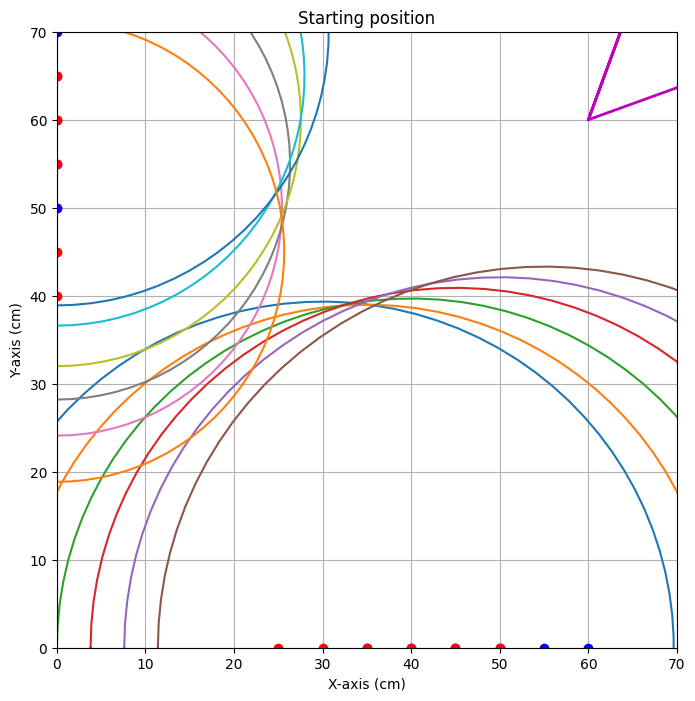


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=60.837


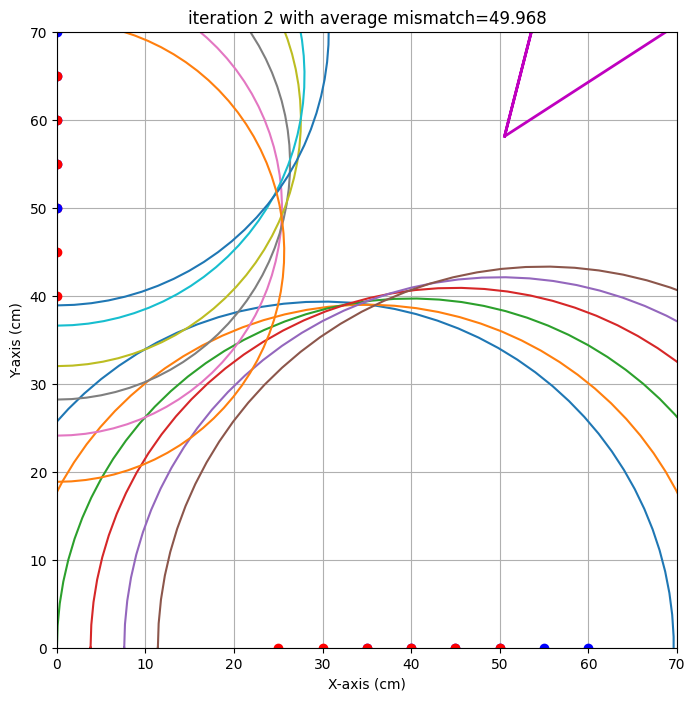

end iteration 2 with average mismatch=49.968


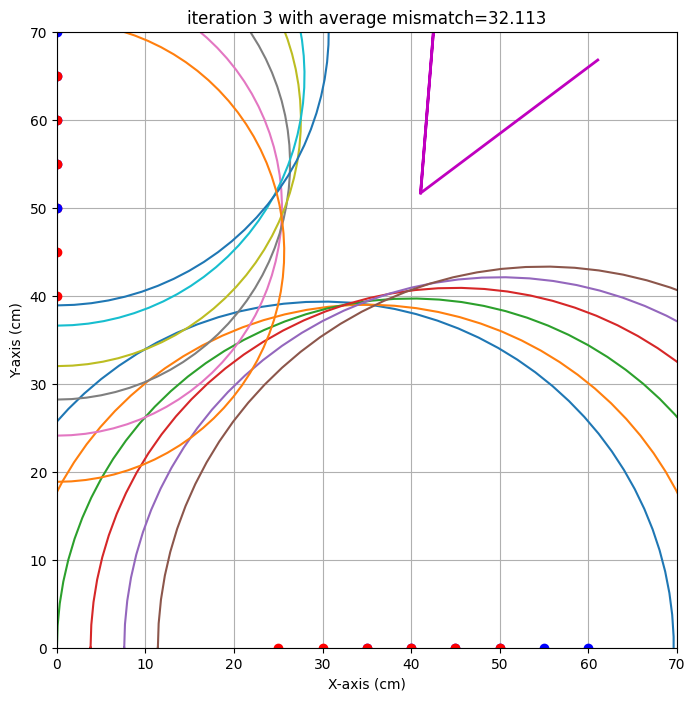

end iteration 3 with average mismatch=32.113


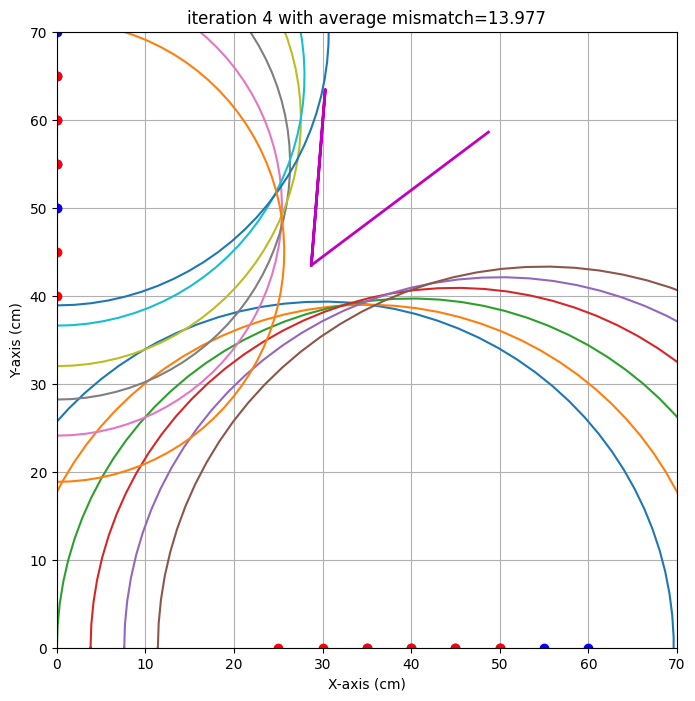

end iteration 4 with average mismatch=13.977


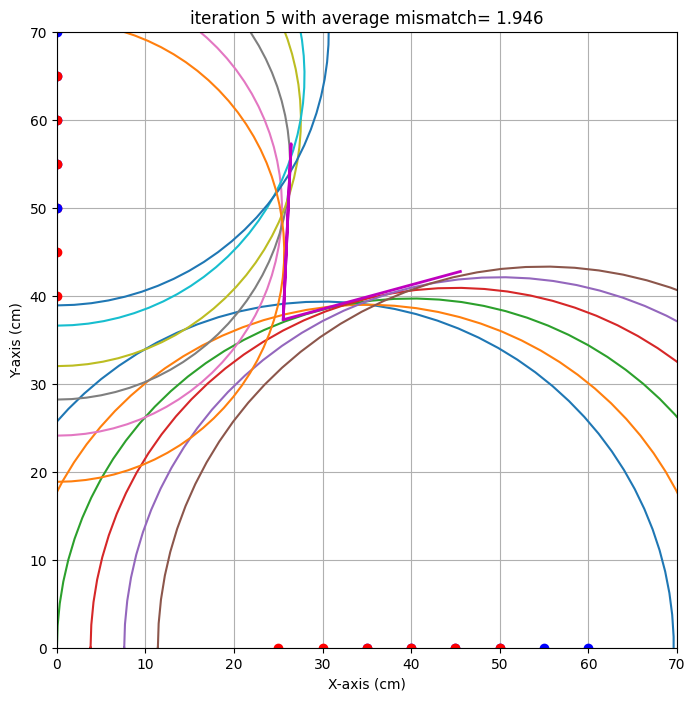

end iteration 5 with average mismatch= 1.946


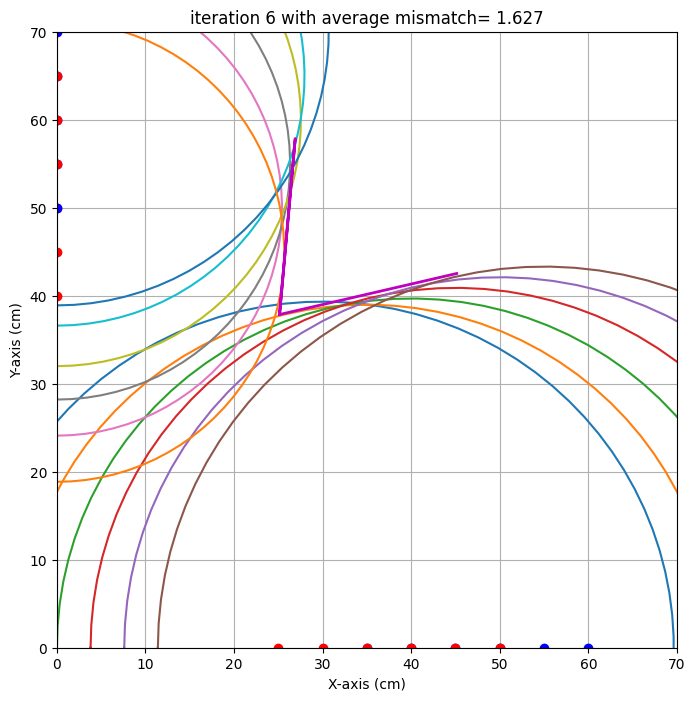

end iteration 6 with average mismatch= 1.627
end iteration 7 with average mismatch= 1.550
end iteration 8 with average mismatch= 1.550
end iteration 9 with average mismatch= 1.550
end iteration 10 with average mismatch= 1.550
end iteration 11 with average mismatch= 1.550
end iteration 12 with average mismatch= 1.550
end iteration 13 with average mismatch= 1.550
end iteration 14 with average mismatch= 1.550
end iteration 15 with average mismatch= 1.550
end iteration 16 with average mismatch= 1.550
end iteration 17 with average mismatch= 1.512
end iteration 18 with average mismatch= 1.506
end iteration 19 with average mismatch= 1.491
end iteration 20 with average mismatch= 1.490
end iteration 21 with average mismatch= 1.489
end iteration 22 with average mismatch= 1.489
end iteration 23 with average mismatch= 1.489
end iteration 24 with average mismatch= 1.489
end iteration 25 with average mismatch= 1.489
end iteration 26 with average mismatch= 1.488
end iteration 27 with average mismatch

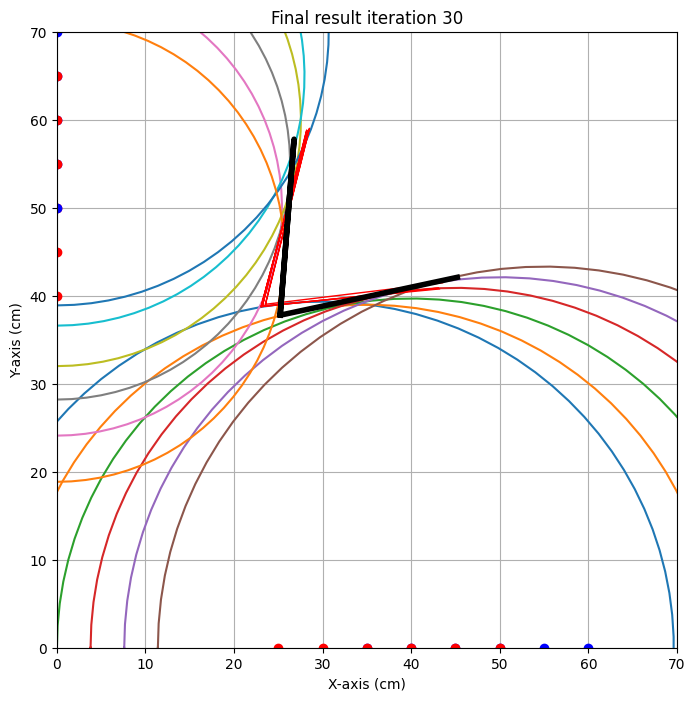

{'alpha': np.float64(12.138080330126757), 'alpha_eps': np.float64(6.588894982303405), 'beta': np.float64(4.502456108751733), 'beta_eps': np.float64(10.343176907881011), 'x0': np.float64(25.20405174969088), 'x0_eps': np.float64(2.1424524231786286), 'y0': np.float64(37.787340780681056), 'y0_eps': np.float64(1.2379829372921307)}
test locatie 
x0 target is : 25.0. Gevonden waarde: 25.2 cm met een standaardafwijking van 2.1 cm 
y0 target is : 39.0. Gevonden waarde: 37.8 cm met een standaardafwijking van 1.2 cm 
alpha target is : 14.0. Gevonden waarde: 12.1 graden met een standaardafwijking van 6.6 graad 
beta target is : 10.0. Gevonden waarde: 4.5 graden met een standaardafwijking van 10.3 graad 



In [13]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':25,  # zelf aanvullen,
                    'y0':39,  # zelf aanvullen,
                    'alpha' :14,  # zelf aanvullen,
                    'beta' :10,  # zelf aanvullen
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[20, 0, 30, 0, 81.2],
    [25, 0, 35, 0, 79.3],
    [30, 0, 40, 0, 78.6],
    [35, 0, 45, 0, 80.0],
    [40, 0, 50, 0, 82.4],
    [45, 0, 55, 0, 84.8],
    [50, 0, 60, 0, 87.2],
    [0, 45, 0, 55, 51.8],
    [0, 50, 0, 60, 53.6],
    [0, 55, 0, 65, 56.0],
    [0, 60, 0, 70, 56.8],
    [0, 65, 0, 75, 62.2],
    [0, 40, 0, 50, 52.3],
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

Verklaring afwijking y0:

De y afstand wijkt 1.2 cm af van de verwachte waarde, ookal is de standaardafwijking een stuk kleiner dan bij de x afstand. Waarschijnlijk komt deze afwijkende waarde door een systematische fout. Het opmeten van de werkelijke y afstand kan invloed op deze afwijking hebben. Verder kan de gemeten waarde ook beïnvloed worden door het feit dat er een afwijking van enkele graden in de hoek zit. Het algoritme probeert een model te fitten wat het best bij de meetpunten past. Het kan zijn dat het daarbij een iets afwijkende y waarde kiest om een beter passende hoek te krijgen.

## Opdracht 11: Leerdoelen.
Eerste algoritme: ![Alt](algoritme3.jpg "Title")


Geïtereerde algoritme: ![Alt](AlgoritmeFinal.jpg "Title")
Eerste iteratie was meer metingen op kleinere afstanden om onzekerheden weg te werken, dit bleek niet genoeg te helpen. Daarna hebben we bij iteratie 2 metingen gedaan over de hele breedte. Waarbij elke 5 centimeter een meting gedaan werd totdat er geen waarde meer uitkwam. Dit bleek te werken, hiermee is de uiteindelijke test uitgevoerd.
